In [10]:
import sys
sys.path.insert(0, "/home/chenyh/workspace/fluProfiler/src/fluprofiler")
import models.architectures  # noqa: F401 — 确保 models 已加载

import seaborn as sns
import matplotlib.pyplot as plt
import torch
import json
import pandas as pd
import torch.nn.functional as F
import numpy as np
from utilities import load_embedding
from sklearn.decomposition import PCA
from torch.utils.data import Dataset, DataLoader
from utilities import print_exams
import matplotlib.pyplot as plt

class fluProfiler_Dataset(Dataset):
    def __init__(self, DataFrame):
        self.emb_file_name_a = ('matrix_' + DataFrame['seq_id_a']).tolist()
        self.emb_file_name_b = ('matrix_' + DataFrame['seq_id_b']).tolist()
        self.emb_file_name_c = ('matrix_' + DataFrame['seq_id_c']).tolist()
        self.emb_file_name_d = ('matrix_' + DataFrame['seq_id_d']).tolist()

        self.strainPassCats = convert_Pass2tensor(('<cls>' + DataFrame['serumPassCat'] + '<eos>' + DataFrame['virusPassCat'] + '<eos>').tolist())

        self.labels = torch.tensor(DataFrame['label'].tolist())
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.emb_file_name_a[idx], self.emb_file_name_b[idx], self.emb_file_name_c[idx], self.emb_file_name_d[idx], \
               self.strainPassCats[idx], self.labels[idx]

def convert_Pass2tensor(pass_cats):
    result = [
        item.replace('<cls>', '0').replace('<eos>', '1').replace('<EGG>', '2').replace('<CELL>', '3').replace('<BOTH>', '4').replace('<NONE>', '5')
        for item in pass_cats
    ]
    result = torch.tensor([[int(number) for number in [char for char in item]] for item in result])
    return result
 
def generate_matrix(matrix_list):
    seq_len = [mat.shape[0] for mat in matrix_list]
    max_len = max(seq_len)
    mask_list = []
    for i in range(len(matrix_list)): 
        matrix_list[i] = F.pad(matrix_list[i], (0, 0, 0, max_len - seq_len[i]))
        mask = torch.concat((torch.ones(1,seq_len[i]),torch.zeros(1,max_len-seq_len[i])),axis=1)
        mask_list.append(mask)
    matrix = torch.stack(matrix_list)
    mask = torch.stack(mask_list).view(len(matrix_list),max_len)
    return matrix, mask

def plot_vaccine_top_bar(
    vaccine,
    prediction_col="prediction",
    vaccine_col="vaccine",
    top_n=25,
    highlight_vaccines=None,
    title=None,
    xlabel="Predicted coverage score",
    figsize=(4, 3.4),
    bar_color="#2E6F8E",
    savefig=None,
    transparent=True,
    show_if_no_save=True):
    if isinstance(highlight_vaccines, str):
        highlight = {highlight_vaccines}
    elif highlight_vaccines is None:
        highlight = set()
    else:
        highlight = set(highlight_vaccines)

    sns.set_theme(style="ticks", context="paper")
    plt.rcParams.update({
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 7,
        "axes.linewidth": 0.8,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "figure.dpi": 300,
    })

    top20 = (
        vaccine.sort_values(prediction_col, ascending=False)
        .drop_duplicates(subset=[vaccine_col], keep="first")
        .head(top_n)
        .copy()
    )
    top20["vaccine_label"] = (
        top20[vaccine_col]
        .str.replace(r"^A/", "", regex=True)
        .str.replace(" EGG", " (EGG)")
        .str.replace(" CELL", " (CELL)")
    )
    ycol = "vaccine_label"

    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=top20,
        y=ycol,
        x=prediction_col,
        color=bar_color,
        edgecolor="none",
        ax=ax,
    )
    ax.axvline(0, color="0.2", lw=0.8)
    ax.xaxis.grid(True, which="major", color="0.9", lw=0.6)
    ax.yaxis.grid(False)
    sns.despine(ax=ax, left=True, bottom=False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.set_title(title, pad=6)
    ax.tick_params(axis="y", pad=2)

    xmin = top20[prediction_col].min()
    xmax = top20[prediction_col].max()
    pad = (xmax - xmin) * 0.06 if xmax > xmin else 0.1
    ax.set_xlim(xmin - pad, xmax + pad)

    labels = [
        ("★ " + name) if name in highlight else name for name in top20[vaccine_col]
    ]
    ax.set_yticklabels(labels)

    fig.tight_layout()
    if savefig is not None:
        plt.savefig(savefig, transparent=transparent)
    elif show_if_no_save:
        plt.show()
    return fig, ax

def build_cross_test_dataloader(
    serum,
    virus,
    batch_size=128,
    shuffle=False,
    label=0):
    """Construct the Cartesian product of H3_serum and H3_virus, and build the fluProfiler Dataset and DataLoader."""
    test_df = serum.merge(virus, how="cross")
    test_df["label"] = label
    test_dataset = fluProfiler_Dataset(test_df)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=shuffle)
    return test_df, test_dataloader

def build_vaccine_table(
    test_df,
    group_cols=("seq_a", "seq_b", "serumPassCat"),
    prediction_col="prediction",
    output_csv=None,
    flip_prediction=True,
    prediction_shift=2.0,
    clip_negative=False,
    weight_by_collection_date=False,
    date_col="virusDate"):

    test_df = test_df.copy()
    if clip_negative:
        test_df[prediction_col] = test_df[prediction_col].clip(lower=0)

    keep_cols = ["serumName", "serumIslID"]
    if group_cols == ("seq_a", "seq_b", "serumPassCat", "serumName"):
        keep_cols = ["seq_id_a", "seq_id_b", "serumIslID"]

    if weight_by_collection_date:
        date_series = pd.to_datetime(test_df[date_col], errors="coerce")
        ordinals = date_series.map(lambda x: x.toordinal() if pd.notna(x) else np.nan)

        if ordinals.notna().any() and ordinals.max() != ordinals.min():
            scaled = (ordinals - ordinals.min()) / (ordinals.max() - ordinals.min())
            test_df["_date_weight"] = np.exp(3 * scaled)
        else:
            test_df["_date_weight"] = 1.0

        test_df["_date_weight"] = test_df["_date_weight"].fillna(1.0)

        def summarize_group(group):
            row = {col: group[col].iloc[0] for col in keep_cols}
            row[prediction_col] = np.average(group[prediction_col], weights=group["_date_weight"])
            return pd.Series(row)

        vaccine = (
            test_df
            .groupby(list(group_cols), as_index=False)
            .apply(summarize_group, include_groups=False)
            .reset_index(drop=True)
        )
    else:
        agg_dict = {prediction_col: "mean", **{col: "first" for col in keep_cols}}
        vaccine = (
            test_df
            .groupby(list(group_cols))
            .agg(agg_dict)
            .reset_index()
        )

    vaccine["vaccine"] = (
        vaccine["serumName"]
        + " "
        + vaccine["serumPassCat"].str.replace("<", "", regex=False).str.replace(">", "", regex=False)
    )

    if flip_prediction:
        vaccine[prediction_col] = vaccine[prediction_col] * -1 + prediction_shift

    vaccine = vaccine.sort_values(by=prediction_col, ascending=False).reset_index(drop=True)

    if output_csv is not None:
        vaccine.to_csv(output_csv, index=False)

    return vaccine

def predict_antigenic_distance(model_path, test_dataloader, emb_dict, device):
    model = torch.load(model_path, weights_only=False, map_location=device)
    prediction_ls_test = []
    reference_ls_test = []
    logits_ls = []
    loss_ls_test = []
    model.eval()
    for batch in test_dataloader:
        emb_file_name_a, emb_file_name_b, emb_file_name_c, emb_file_name_d, strainPassCats, labels = batch

        matrixs_a, masks_a = generate_matrix([emb_dict[key] for key in emb_file_name_a])
        matrixs_b, masks_b = generate_matrix([emb_dict[key] for key in emb_file_name_b])
        matrixs_c, masks_c = generate_matrix([emb_dict[key] for key in emb_file_name_c])
        matrixs_d, masks_d = generate_matrix([emb_dict[key] for key in emb_file_name_d])

        # matrixs_a, matrixs_b, matrixs_c, matrixs_d = matrixs_a.to(device), matrixs_b.to(device), matrixs_c.to(device), matrixs_d.to(device)
        masks_a = masks_a.to(device)
        masks_b = masks_b.to(device)
        masks_c = masks_c.to(device)
        masks_d = masks_d.to(device)

        strainPassCats = strainPassCats.to(device)

        labels = labels.to(device)
        with torch.no_grad():
            loss, logits, output = model(matrices_a=matrixs_a, matrices_b=matrixs_b, matrices_c=matrixs_c,
                                            matrices_d=matrixs_d, matrix_attention_masks_a=masks_a, matrix_attention_masks_b=masks_b,
                                            matrix_attention_masks_c=masks_c, matrix_attention_masks_d=masks_d, strainPassCats=strainPassCats,
                                            labels=labels)

        loss_ls_test.append(loss.item())
        logits_ls.append(logits.tolist())
        prediction_ls_test.extend(output.view(-1).tolist())
        reference_ls_test.extend(labels.tolist())

    return prediction_ls_test

def load_embeddings_from_tables(serum_df, virus_df, emb_dir, device):
    seq_names = pd.concat([serum_df["seq_id_a"], serum_df["seq_id_b"],
                           virus_df["seq_id_c"], virus_df["seq_id_d"]]).unique().tolist()
    file_names = [f"matrix_{seq_id}.pt" for seq_id in seq_names]
    return load_embedding(emb_dir, files=file_names, map_location=device)

def prepare_tables(early_df, target_df, subtype, 
                   serum_group_columns=['seq_a', 'seq_b', 'serumPassCat'], 
                   serum_agg_dict={'seq_id_a': 'first', 'seq_id_b': 'first', 'label': 'mean', 'serumName': 'first', 'serumIslID': 'first'},
                   virus_group_columns=['seq_c', 'seq_d', 'virusPassCat'], 
                   virus_agg_dict={'seq_id_c': 'first', 'seq_id_d': 'first', 'label': 'mean', 'virusName': 'first', 'virusDate': 'first', 'virusIslID': 'first'},
                   extra=None):

    candidate_df = pd.concat([early_df, target_df], ignore_index=True)
    serum = candidate_df[candidate_df["Type"] == subtype].groupby(serum_group_columns).agg(serum_agg_dict).reset_index()
    virus = target_df[target_df["Type"] == subtype].groupby(virus_group_columns).agg(virus_agg_dict).reset_index()

    if extra is not None:
        serum = pd.concat([serum, extra], ignore_index=True)

    return serum, virus

In [11]:
Crick_data = pd.read_csv('../../data/reverse_test/processed/All.csv')

In [12]:
device = torch.device('cuda:6')
columns = ['seq_id_a', 'seq_id_b', 'seq_id_c', 'seq_id_d', 'seq_a', 'seq_b', 'seq_c', 'seq_d', 
           'serumPassCat', 'virusPassCat', 'serumName', 'virusName', 'serumDate', 'virusDate', 
           'Type', 'serumIslID', 'virusIslID', 'label']
           
Crick_early = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] <= '38', columns]
Crick_2023Feb = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '39', columns]
Crick_2023Sep = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '40', columns]
Crick_2024Feb = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '41', columns]
Crick_2024Sep = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '42', columns]
Crick_2025Feb = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '43', columns]
Crick_2025Sep = Crick_data.loc[Crick_data['sheet'].str.split('-', n=1, expand=True)[0] == '44', columns]

who_2023Feb = ["A/DARWIN/9/2021 EGG", "A/DARWIN/6/2021 CELL"]
who_2023Sep = ["A/THAILAND/8/2022 EGG", "A/MASSACHUSETTS/18/2022 CELL"]
who_2024Feb = ["A/THAILAND/8/2022 EGG", "A/MASSACHUSETTS/18/2022 CELL"]
who_2024Sep = ["A/CROATIA/10136RV/2023 EGG", "A/DISTRICTOFCOLUMBIA/27/2023 CELL"]
who_2025Feb = ["A/CROATIA/10136RV/2023 EGG", "A/DISTRICTOFCOLUMBIA/27/2023 CELL"]
who_2025Sep = ['A/SINGAPORE/GP20238/2024 EGG', 'A/SYDNEY/1359/2024 CELL']

serum_group_columns = ['seq_a', 'seq_b', 'serumPassCat']
serum_agg_dict = {'seq_id_a': 'first', 'seq_id_b': 'first', 'label': 'mean', 'serumName': 'first', 'serumIslID': 'first'}
virus_group_columns = ['seq_c', 'seq_d', 'virusPassCat']
virus_agg_dict = {'seq_id_c': 'first', 'seq_id_d': 'first', 'label': 'mean', 'virusName': 'first', 'virusDate': 'first', 'virusIslID': 'first'}

## 1. Vaccine recommendation

### 1.1 2023-2024 NH

In [13]:
## add Darwin cell record
with open("../data/supplementary_vaccines.json", "r", encoding="utf-8") as f:
    sup_vaccine = pd.DataFrame(json.load(f).values())
serum_H3_2023Feb, virus_H3_2023Feb = prepare_tables(Crick_early, Crick_2023Feb, 'H3N2', extra=sup_vaccine)
emb_dict_2023Feb = load_embeddings_from_tables(serum_H3_2023Feb, virus_H3_2023Feb, '../../data/reverse_test/embedding', device)

Loading tensor: 100%|██████████| 472/472 [00:17<00:00, 27.12file/s]


(<Figure size 1200x1020 with 1 Axes>,
 <Axes: xlabel='Predicted coverage score'>)

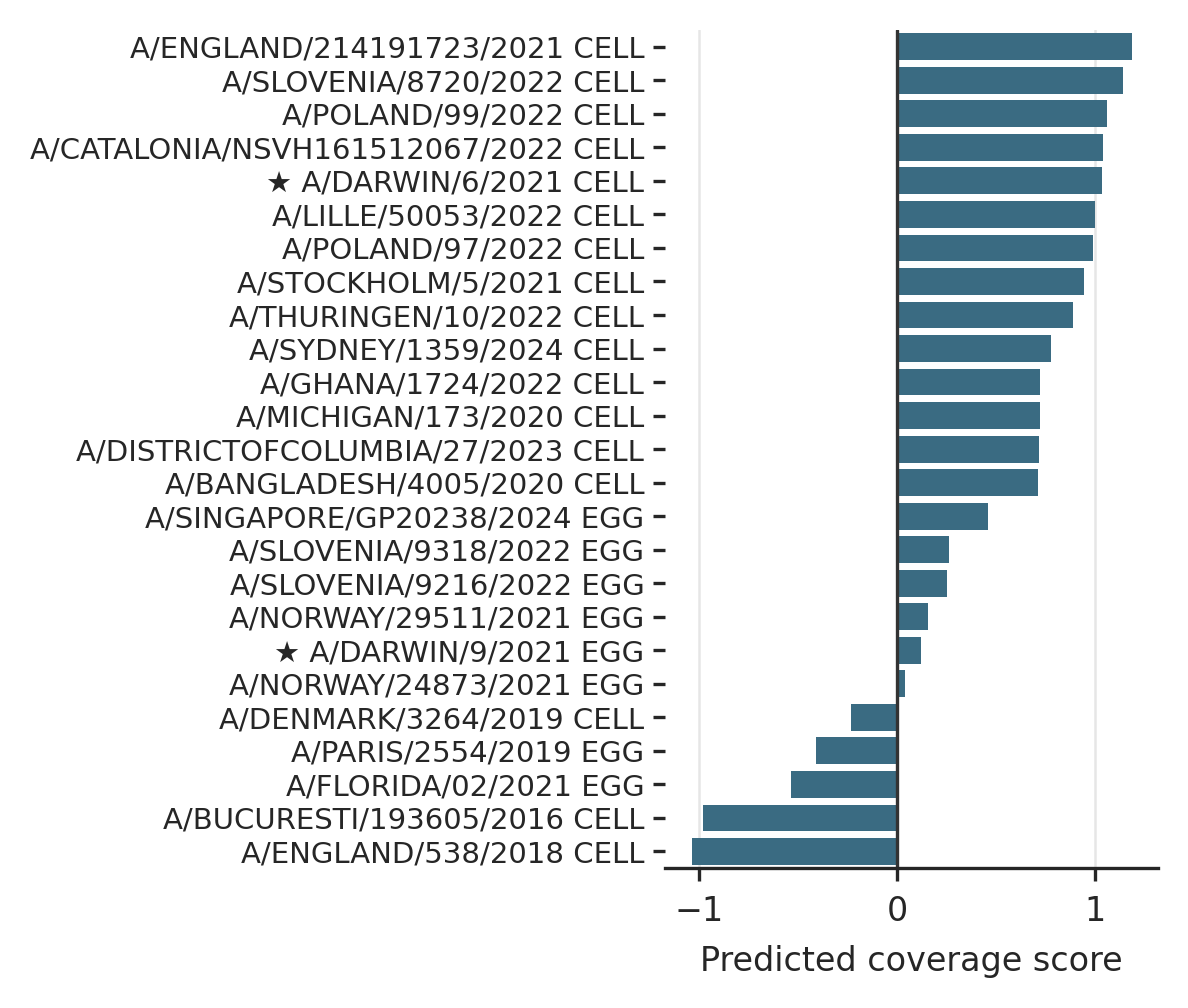

In [14]:
test_df_2023Feb, test_dataloader_2023Feb = build_cross_test_dataloader(serum_H3_2023Feb, virus_H3_2023Feb, label=0)
model_path = '../../runs/reverse_tests/2023NH/v3_2/20260311_035456__v3_2_cached__pid2718573/checkpoints/2026-03-11_06-54-05.pth'
test_df_2023Feb['prediction'] = predict_antigenic_distance(model_path, test_dataloader_2023Feb, emb_dict_2023Feb, device)
vaccine_2023Feb = build_vaccine_table(test_df_2023Feb, clip_negative=True, weight_by_collection_date=True)
plot_vaccine_top_bar(vaccine_2023Feb, highlight_vaccines=who_2023Feb, savefig='../Figure/Fig4A.svg')

### 1.2 2024 SH

In [15]:
## add Darwin cell record
who_vac = Crick_2024Feb[Crick_2024Feb['serumName'].isin([f.split(' ')[0] for f in who_2023Sep])].groupby(serum_group_columns).agg(serum_agg_dict).reset_index()
serum_H3_2023Sep, virus_H3_2023Sep = prepare_tables(pd.concat([Crick_early, Crick_2023Feb]), Crick_2023Sep, 'H3N2', extra=who_vac)
emb_dict_2023Sep = load_embeddings_from_tables(serum_H3_2023Sep, virus_H3_2023Sep, '../../data/reverse_test/embedding', device)

Loading tensor: 100%|██████████| 620/620 [00:22<00:00, 27.20file/s]


(<Figure size 1200x1020 with 1 Axes>,
 <Axes: xlabel='Predicted coverage score'>)

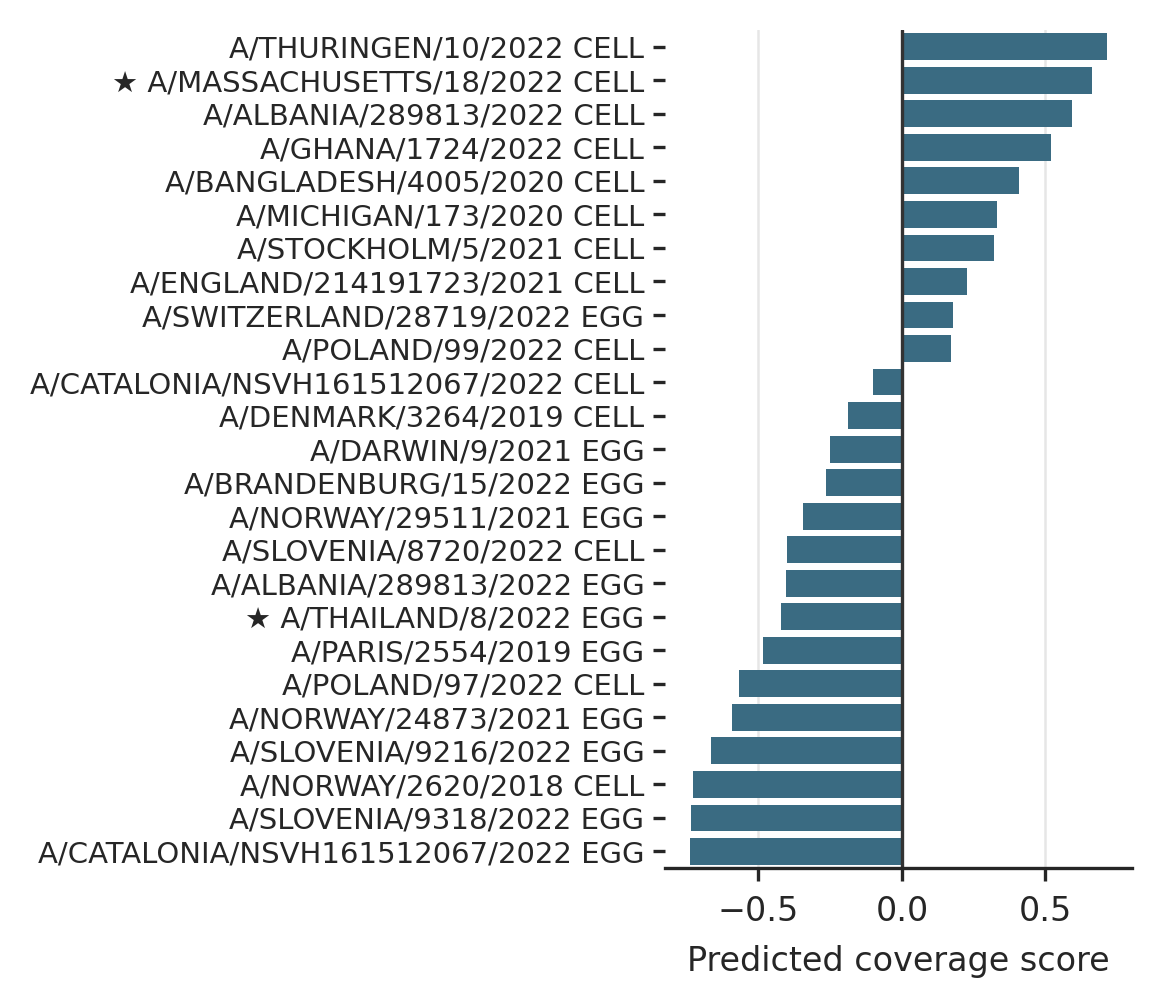

In [16]:
test_df_2023Sep, test_dataloader_2023Sep = build_cross_test_dataloader(serum_H3_2023Sep, virus_H3_2023Sep, label=0)
model_path = '../../runs/reverse_tests/2023SH/v3_2/20260311_042518__v3_2_cached__pid2722163/checkpoints/2026-03-11_10-48-17.pth'
test_df_2023Sep['prediction'] = predict_antigenic_distance(model_path, test_dataloader_2023Sep, emb_dict_2023Sep, device)
vaccine_2023Sep = build_vaccine_table(test_df_2023Sep, clip_negative=True)
plot_vaccine_top_bar(vaccine_2023Sep, highlight_vaccines=who_2023Sep, savefig='../Figure/Fig4B.svg')

### 1.3 2024-2025 NH

In [8]:
## add Darwin cell record
with open("../data/supplementary_vaccines.json", "r", encoding="utf-8") as f:
    sup_vaccine = pd.DataFrame(json.load(f).values())
serum_H3_2024Feb, virus_H3_2024Feb = prepare_tables(pd.concat([Crick_early, Crick_2023Feb, Crick_2023Sep]), Crick_2024Feb, 'H3N2', extra=sup_vaccine)
emb_dict_2024Feb = load_embeddings_from_tables(serum_H3_2024Feb, virus_H3_2024Feb, '../../data/reverse_test/embedding', device)

Loading tensor: 100%|██████████| 464/464 [00:16<00:00, 27.60file/s]


(<Figure size 1200x1020 with 1 Axes>,
 <Axes: xlabel='Predicted coverage score'>)

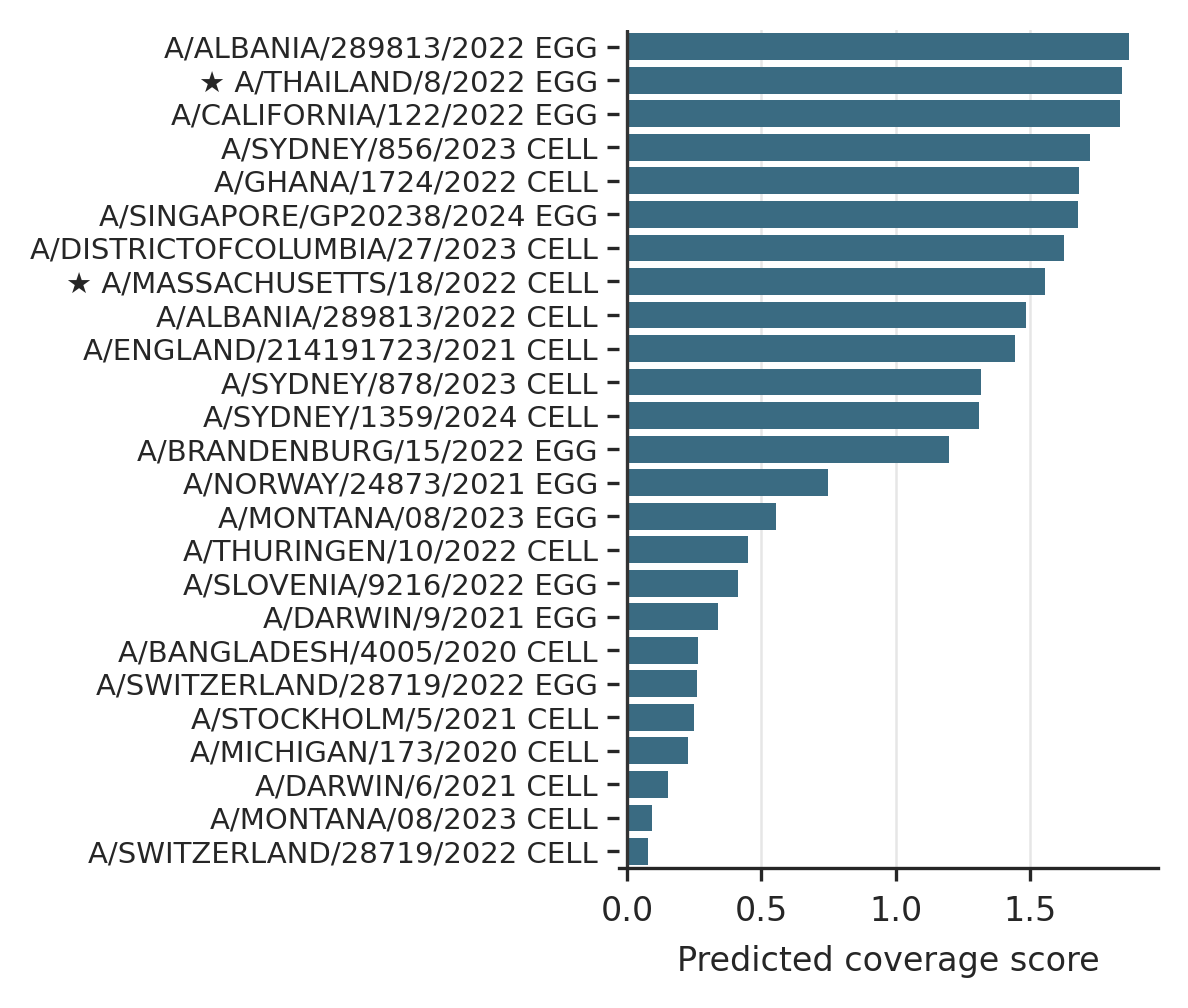

In [9]:
test_df_2024Feb, test_dataloader_2024Feb = build_cross_test_dataloader(serum_H3_2024Feb, virus_H3_2024Feb, label=0)
model_path = '../../runs/reverse_tests/2024NH/v3_2/20260310_210905__v3_2_cached__pid2664025/checkpoints/2026-03-11_03-09-22.pth'
test_df_2024Feb['prediction'] = predict_antigenic_distance(model_path, test_dataloader_2024Feb, emb_dict_2024Feb, device)
vaccine_2024Feb = build_vaccine_table(test_df_2024Feb, clip_negative=True)
plot_vaccine_top_bar(vaccine_2024Feb, highlight_vaccines=who_2024Feb, savefig='../Figure/Fig4C.svg')

### 1.4 2025 SH

In [17]:
## add Darwin cell record
with open("../data/supplementary_vaccines.json", "r", encoding="utf-8") as f:
    sup_vaccine = pd.DataFrame(json.load(f).values())
serum_H3_2024Sep, virus_H3_2024Sep = prepare_tables(pd.concat([Crick_early, Crick_2023Feb, Crick_2023Sep, Crick_2024Feb]),
                                                Crick_2024Sep, 'H3N2', extra=sup_vaccine)
emb_dict_2024Sep = load_embeddings_from_tables(serum_H3_2024Sep, virus_H3_2024Sep, '../../data/reverse_test/embedding', device)

Loading tensor: 100%|██████████| 858/858 [00:31<00:00, 27.07file/s]


(<Figure size 1200x1020 with 1 Axes>,
 <Axes: xlabel='Predicted coverage score'>)

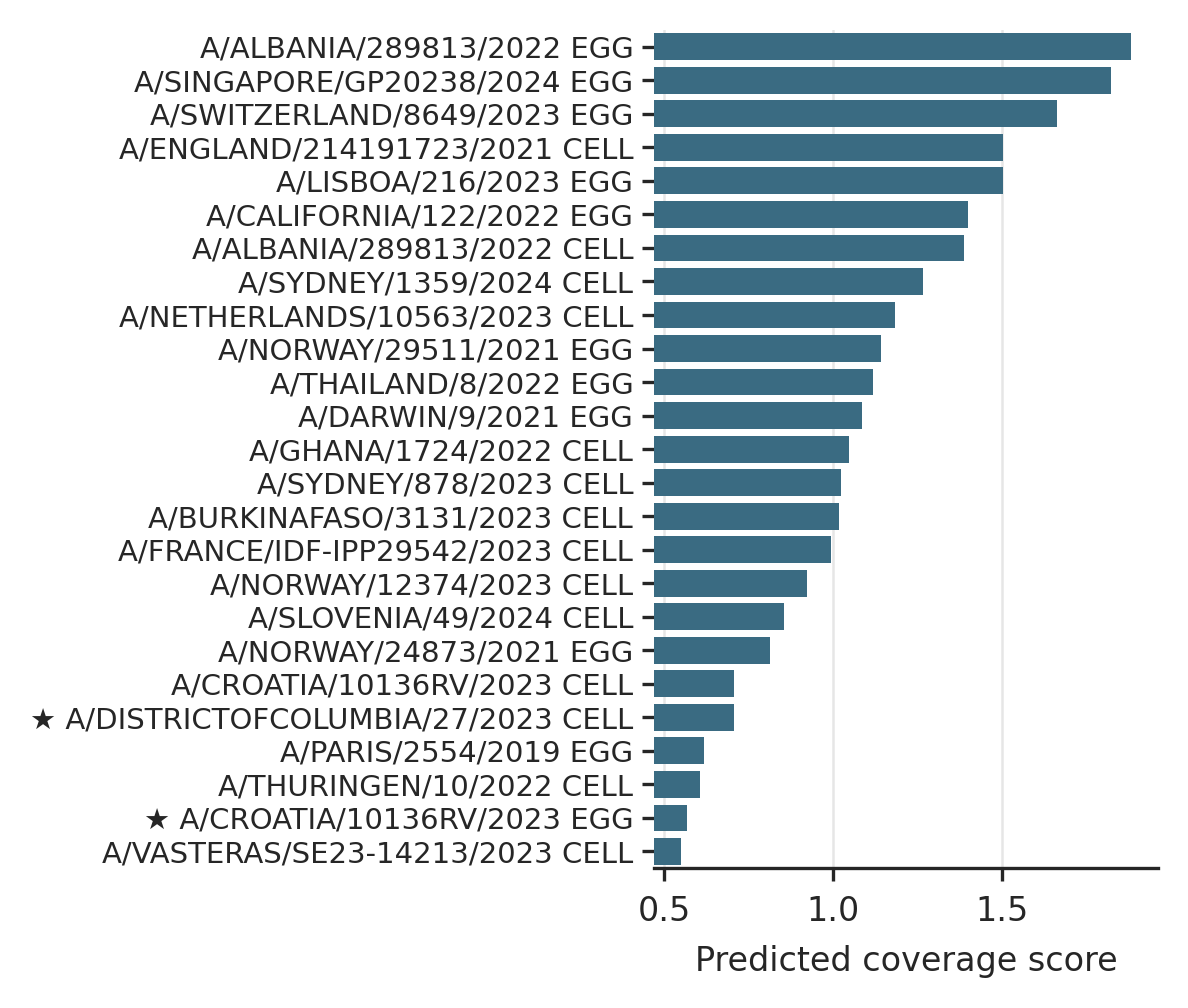

In [18]:
test_df_2024Sep, test_dataloader_2024Sep = build_cross_test_dataloader(serum_H3_2024Sep, virus_H3_2024Sep, label=0)
model_path = '../../runs/reverse_tests/2024SH/v3_2/20260313_115444__v3_2_cached__pid3129031/checkpoints/2026-03-13_16-32-13.pth'
test_df_2024Sep['prediction'] = predict_antigenic_distance(model_path, test_dataloader_2024Sep, emb_dict_2024Sep, device)
vaccine_2024Sep = build_vaccine_table(test_df_2024Sep, group_cols=('seq_a', 'seq_b', 'serumPassCat', 'serumName'), clip_negative=True)
plot_vaccine_top_bar(vaccine_2024Sep, highlight_vaccines=who_2024Sep, savefig='../Figure/Fig4D.svg')

### 1.5 2025-2026 NH

In [19]:
## add Darwin cell record
with open("../data/supplementary_vaccines.json", "r", encoding="utf-8") as f:
    sup_vaccine = pd.DataFrame(json.load(f).values())
serum_H3_2025Feb, virus_H3_2025Feb = prepare_tables(pd.concat([Crick_early, Crick_2023Feb, Crick_2023Sep, Crick_2024Feb, Crick_2024Sep]),
                                                Crick_2025Feb, 'H3N2', extra=sup_vaccine)
emb_dict_2025Feb = load_embeddings_from_tables(serum_H3_2025Feb, virus_H3_2025Feb, '../../data/reverse_test/embedding', device)

Loading tensor: 100%|██████████| 621/621 [00:22<00:00, 27.18file/s]


(<Figure size 1200x1020 with 1 Axes>,
 <Axes: xlabel='Predicted coverage score'>)

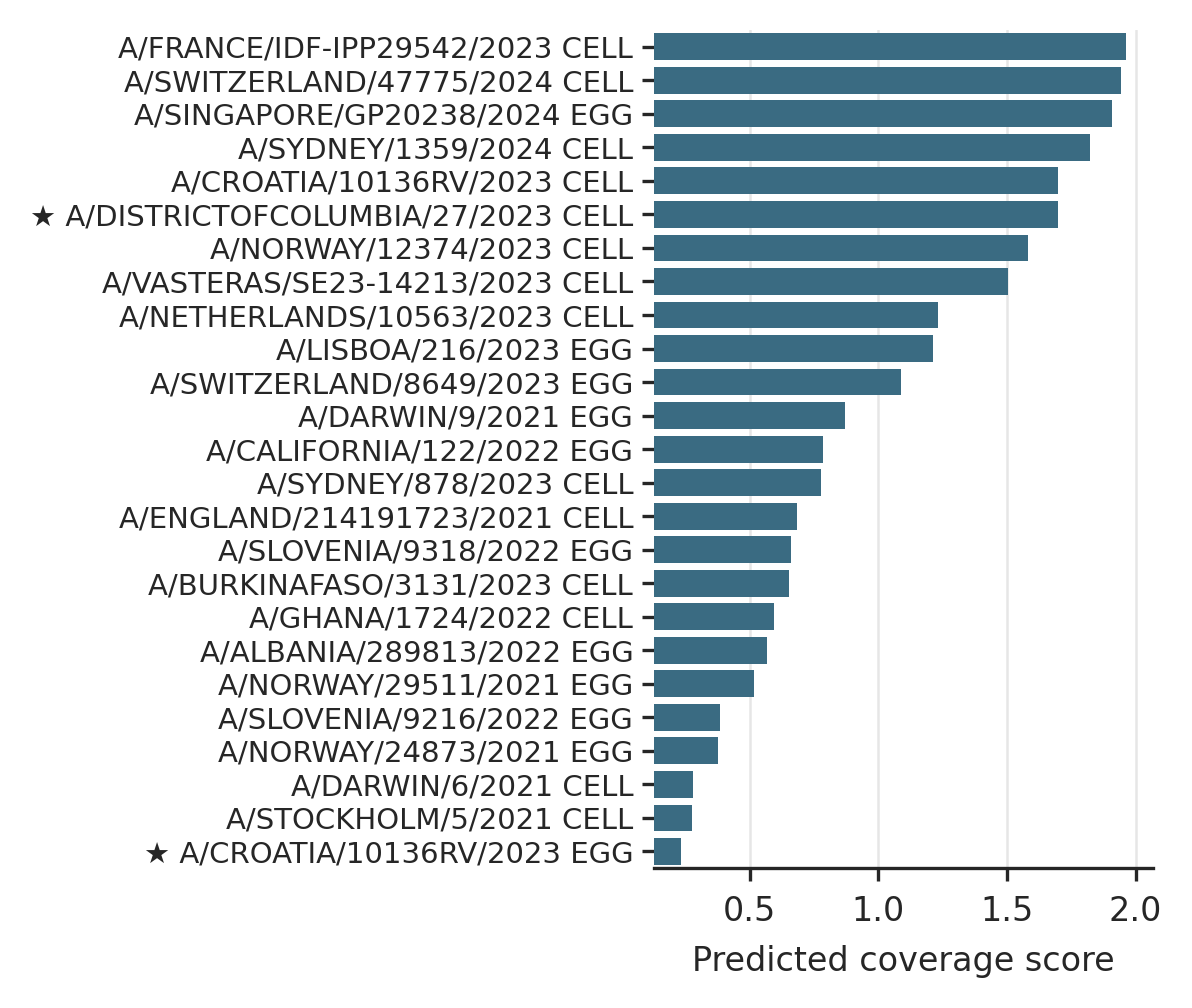

In [20]:
test_df_2025Feb, test_dataloader_2025Feb = build_cross_test_dataloader(serum_H3_2025Feb, virus_H3_2025Feb, label=0)
model_path = '../../runs/reverse_tests/2025NH/v3_2/20260310_222813__v3_2_cached__pid2678417/checkpoints/2026-03-11_05-37-45.pth'
test_df_2025Feb['prediction'] = predict_antigenic_distance(model_path, test_dataloader_2025Feb, emb_dict_2025Feb, device)
vaccine_2025Feb = build_vaccine_table(test_df_2025Feb, group_cols=('seq_a', 'seq_b', 'serumPassCat', 'serumName'), clip_negative=True)
plot_vaccine_top_bar(vaccine_2025Feb, highlight_vaccines=who_2025Feb, savefig='../Figure/Fig4E.svg')

### 1.6 2026SH

In [21]:
## add Darwin cell record
with open("../data/supplementary_vaccines.json", "r", encoding="utf-8") as f:
    sup_vaccine = pd.DataFrame(json.load(f).values())
serum_H3_2025Sep, virus_H3_2025Sep = prepare_tables(pd.concat([Crick_early, Crick_2023Feb, Crick_2023Sep, Crick_2024Feb, Crick_2024Sep, Crick_2025Feb]),
                                                Crick_2025Sep, 'H3N2', extra=sup_vaccine)
emb_dict_2025Sep = load_embeddings_from_tables(serum_H3_2025Sep, virus_H3_2025Sep, '../../data/reverse_test/embedding', device)

Loading tensor: 100%|██████████| 617/617 [00:22<00:00, 27.32file/s]


(<Figure size 1200x1020 with 1 Axes>,
 <Axes: xlabel='Predicted coverage score'>)

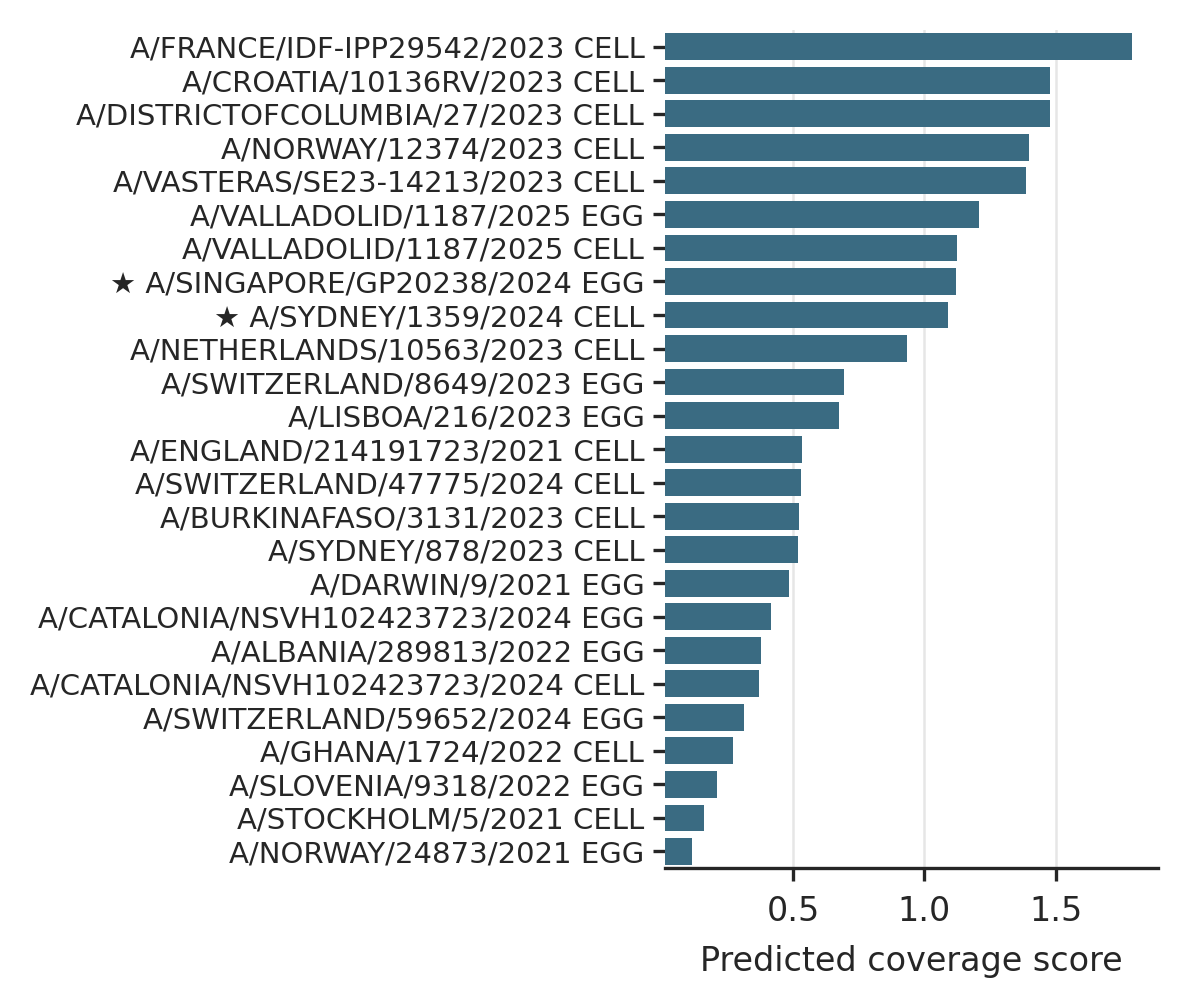

In [22]:
test_df_2025Sep, test_dataloader_2025Sep = build_cross_test_dataloader(serum_H3_2025Sep, virus_H3_2025Sep, label=0)
model_path = '../../runs/reverse_tests/2025SH/v3_2/20260312_110943__v3_2_cached__pid2927488/checkpoints/2026-03-12_16-48-08.pth'
test_df_2025Sep['prediction'] = predict_antigenic_distance(model_path, test_dataloader_2025Sep, emb_dict_2025Sep, device)
vaccine_2025Sep = build_vaccine_table(test_df_2025Sep, group_cols=('seq_a', 'seq_b', 'serumPassCat', 'serumName'), clip_negative=True)
plot_vaccine_top_bar(vaccine_2025Sep, highlight_vaccines=who_2025Sep, savefig='../Figure/Fig4F.svg')

## 2. Antigenic space

In [19]:
import torch.nn as nn

In [20]:
model_path = "/home/chenyh/workspace/fluProfiler/runs/HA_only/split/HA/20260322_101738__HA_only_cached__pid908736/checkpoints/2026-03-22_21-21-28.pth"
profiling_model = torch.load(model_path, weights_only=False, map_location=device)

In [21]:
class Emb2Vec(nn.Module):
    def __init__(self, model):
        super(Emb2Vec, self).__init__()
        self.matrix_dropout = model.matrix_dropout
        self.matrix_pooler = model.matrix_pooler
        self.linear = model.linear[0][0]
        self.Gelu = model.linear[0][1]
        
    def forward(self, embedding):
        embedding = self.matrix_dropout(embedding)
        seq_vector = self.matrix_pooler(embedding)
        seq_vector = self.linear(seq_vector)
        return seq_vector

def run_emb2vec_on_dict(emb_dict, emb2vec, device='cpu'):
    emb2vec = emb2vec.to(device)
    emb2vec.eval()

    vec_dict = {}
    for k, emb in emb_dict.items():
        emb = emb.to(device)
        if emb.dim() == 2:   # (566, 2560) -> (1, 566, 2560)
            emb = emb.unsqueeze(0)

        with torch.no_grad():
            vec = emb2vec(emb)[0].cpu()   # (D_out,)
        vec_dict[k] = vec
    return vec_dict

def retrive_tensor_from_dict(emb_dict, virus_id_list):
    emb_dict = {k: v for k, v in emb_dict.items() if k in virus_id_list
    }
    vector_dict = run_emb2vec_on_dict(emb_dict, embedding_pooler, device=device)
    virus_tensor_list = [v for k, v in vector_dict.items()]
    virus_tensor = torch.stack(virus_tensor_list)
    print(                              virus_tensor.shape)
    return virus_tensor

def plot_pca_groups(emb_dict, target_ids, top_id, who_ids, figsize=(3, 2.5)):
    target_tensor = np.asarray(retrive_tensor_from_dict(emb_dict, target_ids))
    top_tensor = np.asarray(retrive_tensor_from_dict(emb_dict, [top_id]))
    who_tensor = np.asarray(retrive_tensor_from_dict(emb_dict, who_ids))

    X = np.vstack([target_tensor, top_tensor, who_tensor])
    labels = (
        ['target'] * len(target_tensor) +
        ['top'] * len(top_tensor) +
        ['who'] * len(who_tensor)
    )

    X_2d = PCA(n_components=2).fit_transform(X)
    colors = {'target': 'grey', 'top': 'blue', 'who': 'red'}

    plt.figure(figsize=figsize)
    for name in ['target', 'top', 'who']:
        idx = [i for i, x in enumerate(labels) if x == name]
        plt.scatter(
            X_2d[idx, 0], X_2d[idx, 1],
            label=name,
            c=colors[name],
            s=25 if name != 'target' else 15,
            alpha=0.8
        )
    
    # top 到所有 target 的距离
    top_to_target_dist = np.linalg.norm(target_tensor - top_tensor, axis=1)

    # who 到所有 target 的距离
    who_to_target_dist_1 = np.linalg.norm(target_tensor - who_tensor[0, :], axis=1)
    who_to_target_dist_2 = np.linalg.norm(target_tensor - who_tensor[1, :], axis=1)
    print('top avg distance:', top_to_target_dist.mean())
    print('who1 avg distance:', who_to_target_dist_1.mean())
    print('who2 avg distance:', who_to_target_dist_2.mean())

    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

    return X_2d, labels
    

In [22]:
embedding_pooler = Emb2Vec(profiling_model)

### 2.1 2023Feb

In [23]:
virus_id_2023Feb = ('matrix_' + virus_H3_2023Feb['seq_id_c']).unique().tolist()
top_id_2023Feb = 'matrix_' + serum_H3_2023Feb.loc[serum_H3_2023Feb['seq_a'] == vaccine_2023Feb.iloc[0,0], 'seq_id_a'].item()
vaccine_2023Feb_with_id = build_vaccine_table(test_df_2023Feb,group_cols=('seq_a', 'seq_b', 'serumPassCat', 'serumName'))
who_id_2023Feb = ('matrix_' + vaccine_2023Feb_with_id.loc[vaccine_2023Feb_with_id['vaccine'].isin(who_2023Feb),['vaccine', 'seq_id_a']].drop_duplicates()['seq_id_a']).tolist()

torch.Size([175, 256])
torch.Size([1, 256])
torch.Size([2, 256])
top avg distance: 6.731462
who1 avg distance: 7.0339565
who2 avg distance: 7.1173515


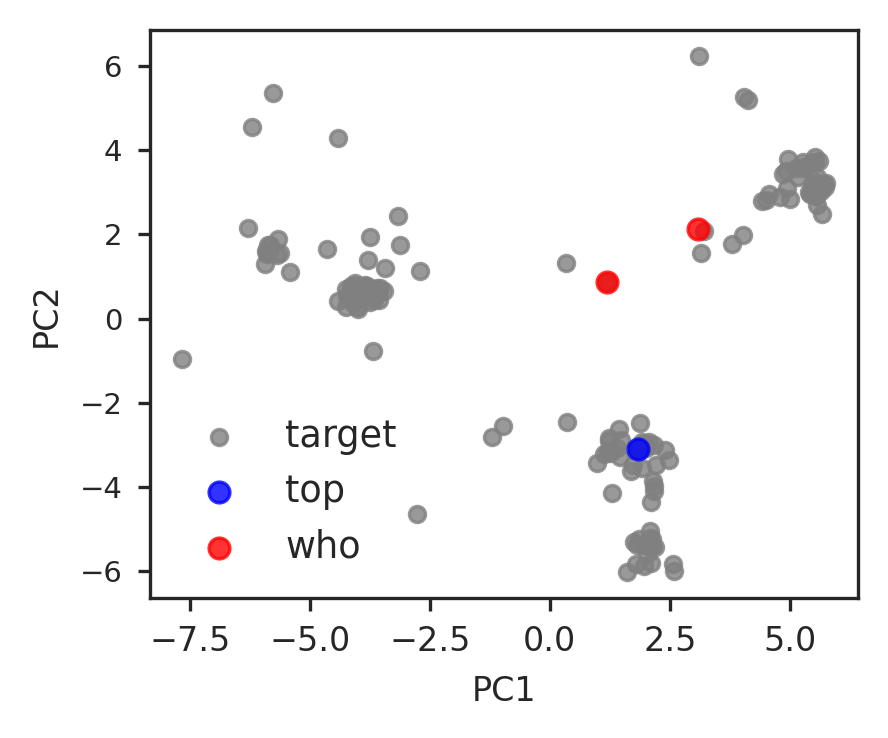

In [24]:
X_2d, labels = plot_pca_groups(
    emb_dict_2023Feb,
    virus_id_2023Feb,
    top_id_2023Feb,
    who_id_2023Feb
)

### 2.2 2023Sep

In [25]:
virus_id_2023Sep = ('matrix_' + virus_H3_2023Sep['seq_id_c']).unique().tolist()
top_id_2023Sep = 'matrix_' + serum_H3_2023Sep.loc[serum_H3_2023Sep['seq_a'] == vaccine_2023Sep.iloc[0,0], 'seq_id_a'].item()
vaccine_2023Sep_with_id = build_vaccine_table(test_df_2023Sep,group_cols=('seq_a', 'seq_b', 'serumPassCat', 'serumName'))
who_id_2023Sep = ('matrix_' + vaccine_2023Sep_with_id.loc[vaccine_2023Sep_with_id['vaccine'].isin(who_2023Sep),['vaccine', 'seq_id_a']].drop_duplicates()['seq_id_a']).tolist()

torch.Size([247, 256])
torch.Size([1, 256])
torch.Size([2, 256])
top avg distance: 6.2050667
who1 avg distance: 8.212143
who2 avg distance: 8.245562


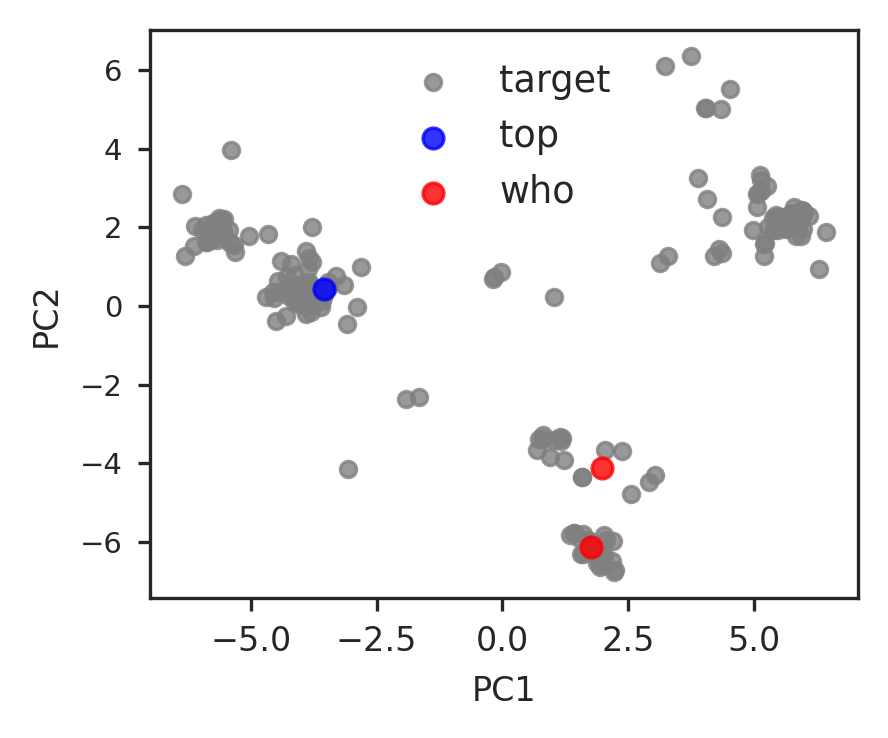

In [26]:
X_2d, labels = plot_pca_groups(
    emb_dict_2023Sep,
    virus_id_2023Sep,
    top_id_2023Sep,
    who_id_2023Sep
)

### 2.3 2024Feb

In [ ]:
virus_id_2024Feb = ('matrix_' + virus_H3_2024Feb['seq_id_c']).unique().tolist()
top_id_2024Feb = 'matrix_' + serum_H3_2024Feb.loc[serum_H3_2024Feb['seq_a'] == vaccine_2024Feb.iloc[0,0], 'seq_id_a'].item()
vaccine_2024Feb_with_id = build_vaccine_table(test_df_2024Feb,group_cols=('seq_a', 'seq_b', 'serumPassCat', 'serumName'))
who_id_2024Feb = ('matrix_' + vaccine_2024Feb_with_id.loc[vaccine_2024Feb_with_id['vaccine'].isin(who_2024Feb),['vaccine', 'seq_id_a']].drop_duplicates()['seq_id_a']).tolist()

torch.Size([136, 256])
torch.Size([1, 256])
torch.Size([2, 256])
top avg distance: 6.567335
who1 avg distance: 6.3779693
who2 avg distance: 5.718591


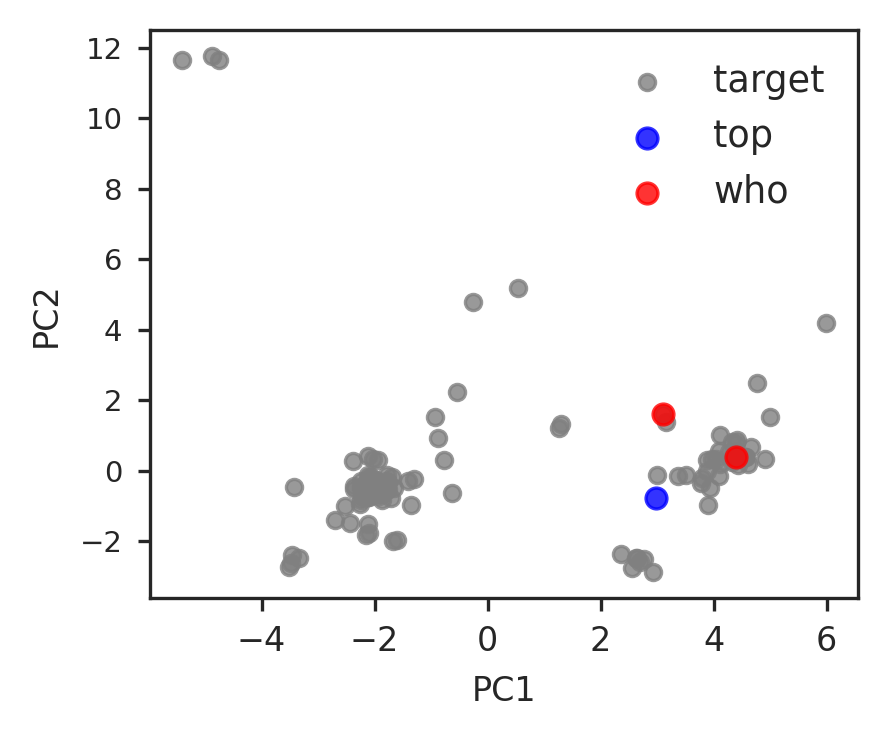

In [28]:
X_2d, labels = plot_pca_groups(
    emb_dict_2024Feb,
    virus_id_2024Feb,
    top_id_2024Feb,
    who_id_2024Feb
)

### 2.4 2024Sep

In [29]:
virus_id_2024Sep = ('matrix_' + virus_H3_2024Sep['seq_id_c']).unique().tolist()
top_id_2024Sep = 'matrix_' + serum_H3_2024Sep.loc[serum_H3_2024Sep['seq_a'] == vaccine_2024Sep.iloc[0,0], 'seq_id_a'].item()
vaccine_2024Sep_with_id = build_vaccine_table(test_df_2024Sep,group_cols=('seq_a', 'seq_b', 'serumPassCat', 'serumName'))
who_id_2024Sep = ('matrix_' + vaccine_2024Sep_with_id.loc[vaccine_2024Sep_with_id['vaccine'].isin(who_2024Sep),['vaccine', 'seq_id_a']].drop_duplicates()['seq_id_a']).tolist()

torch.Size([338, 256])
torch.Size([1, 256])
torch.Size([2, 256])
top avg distance: 6.9458485
who1 avg distance: 7.253386
who2 avg distance: 5.4711413


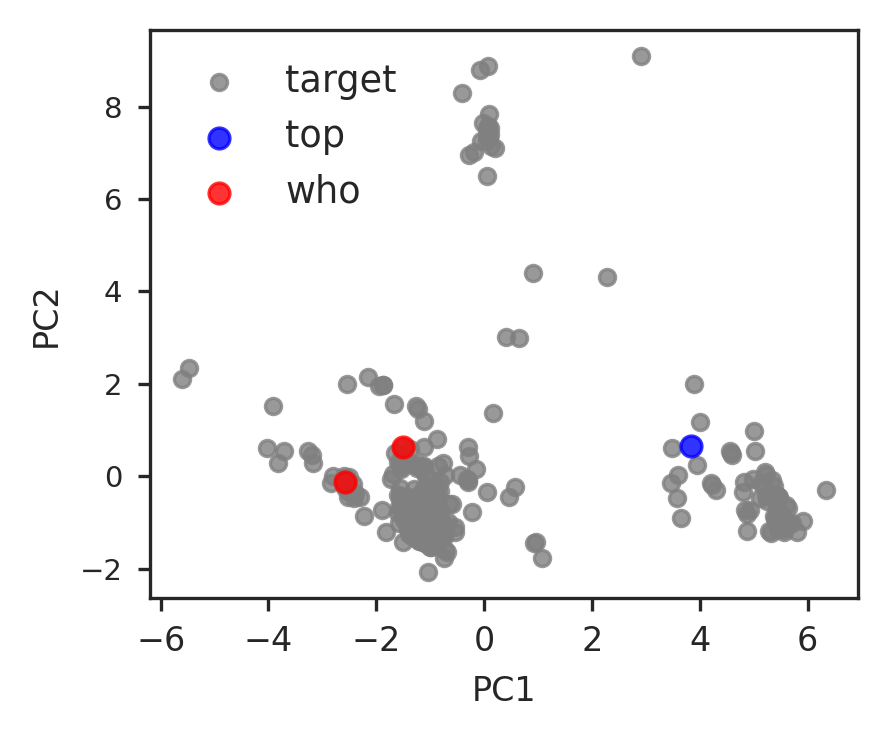

In [30]:
X_2d, labels = plot_pca_groups(
    emb_dict_2024Sep,
    virus_id_2024Sep,
    top_id_2024Sep,
    who_id_2024Sep
)

### 2.5 2025Feb

In [31]:
virus_id_2025Feb = ('matrix_' + virus_H3_2025Feb['seq_id_c']).unique().tolist()
top_id_2025Feb = 'matrix_' + serum_H3_2025Feb.loc[serum_H3_2025Feb['seq_a'] == vaccine_2025Feb.iloc[0,0], 'seq_id_a'].unique().item()
vaccine_2025Feb_with_id = build_vaccine_table(test_df_2025Feb,group_cols=('seq_a', 'seq_b', 'serumPassCat', 'serumName'))
who_id_2025Feb = ('matrix_' + vaccine_2025Feb_with_id.loc[vaccine_2025Feb_with_id['vaccine'].isin(who_2025Feb),['vaccine', 'seq_id_a']].drop_duplicates()['seq_id_a']).tolist()

torch.Size([203, 256])
torch.Size([1, 256])
torch.Size([2, 256])
top avg distance: 8.972105
who1 avg distance: 7.38914
who2 avg distance: 5.346072


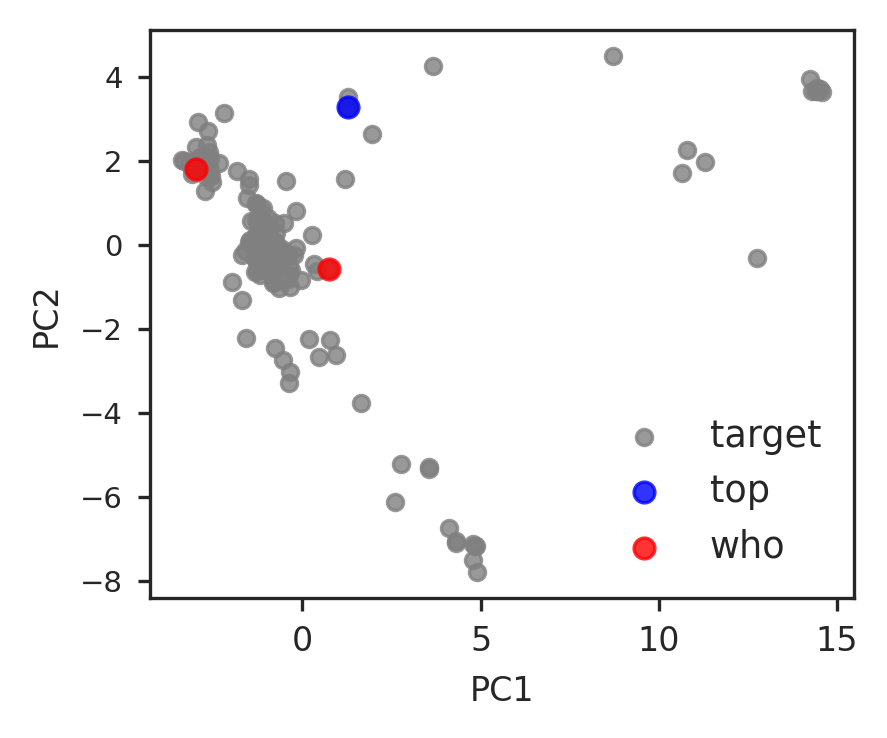

In [32]:
X_2d, labels = plot_pca_groups(
    emb_dict_2025Feb,
    virus_id_2025Feb,
    top_id_2025Feb,
    who_id_2025Feb
)

### 2.6 2025Sep

In [33]:
virus_id_2025Sep = ('matrix_' + virus_H3_2025Sep['seq_id_c']).unique().tolist()
top_id_2025Sep = 'matrix_' + serum_H3_2025Sep.loc[serum_H3_2025Sep['seq_a'] == vaccine_2025Sep.iloc[0,0], 'seq_id_a'].unique().item()
vaccine_2025Sep_with_id = build_vaccine_table(test_df_2025Sep,group_cols=('seq_a', 'seq_b', 'serumPassCat', 'serumName'))
who_id_2025Sep = ('matrix_' + vaccine_2025Sep_with_id.loc[vaccine_2025Sep_with_id['vaccine'].isin(who_2025Sep),['vaccine', 'seq_id_a']].drop_duplicates()['seq_id_a']).tolist()

torch.Size([209, 256])
torch.Size([1, 256])
torch.Size([2, 256])
top avg distance: 9.302629
who1 avg distance: 15.219492
who2 avg distance: 13.801092


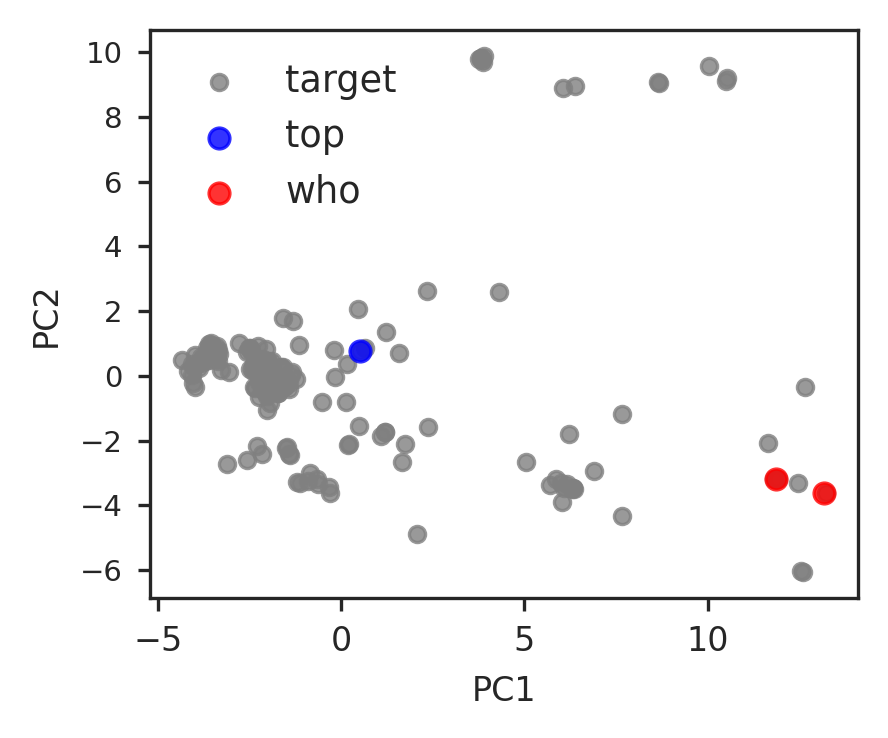

In [34]:
X_2d, labels = plot_pca_groups(
    emb_dict_2025Sep,
    virus_id_2025Sep,
    top_id_2025Sep,
    who_id_2025Sep
)

## All

In [35]:
import matplotlib.patheffects as pe

In [36]:
def plot_all_target_top_who(season_inputs, figsize=(8, 6)):
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA

    all_vecs, rows = [], []
    season_names = list(season_inputs.keys())

    for season, cfg in season_inputs.items():
        target_ids = cfg["target_ids"]
        top_id = cfg["top_id"]
        who_ids = cfg["who_ids"]
        emb_dict = cfg["emb_dict"]

        target_tensor = np.asarray(retrive_tensor_from_dict(emb_dict, target_ids))
        top_tensor = np.asarray(retrive_tensor_from_dict(emb_dict, [top_id]))
        who_tensor = np.asarray(retrive_tensor_from_dict(emb_dict, who_ids))

        for i, vid in enumerate(target_ids):
            all_vecs.append(target_tensor[i])
            rows.append({"season": season, "name": vid, "group": "target"})
        all_vecs.append(top_tensor[0])
        rows.append({"season": season, "name": top_id, "group": "top"})
        for i, vid in enumerate(who_ids):
            all_vecs.append(who_tensor[i])
            rows.append({"season": season, "name": vid, "group": "who"})

    X = np.vstack(all_vecs)
    XY = PCA(n_components=2).fit_transform(X)

    df = pd.DataFrame(rows)
    df["x"], df["y"] = XY[:, 0], XY[:, 1]

    cmap = plt.cm.viridis
    season_colors = {
        season: cmap(1 - i / max(len(season_names) - 1, 1))
        for i, season in enumerate(season_names)
    }

    markers = {"target": "o", "top": "^", "who": "*"}
    sizes = {"target": 20, "top": 90, "who": 120}
    group_colors = {"top": "red", "who": "blue"}

    plt.figure(figsize=figsize)

    for season in season_names:
        sub = df[(df["season"] == season) & (df["group"] == "target")]
        if len(sub) > 0:
            plt.scatter(
                sub["x"], sub["y"],
                c=[season_colors[season]],
                marker=markers["target"],
                s=sizes["target"],
                alpha=0.85,
                label=f"{season} target"
            )

    sub = df[df["group"] == "top"]
    plt.scatter(
        sub["x"], sub["y"],
        c=group_colors["top"],
        marker=markers["top"],
        s=sizes["top"],
        alpha=0.85,
        label="top"
    )

    sub = df[df["group"] == "who"]
    plt.scatter(
        sub["x"], sub["y"],
        c=group_colors["who"],
        marker=markers["who"],
        s=sizes["who"],
        alpha=0.85,
        label="who"
    )

    # 按 season 顺序排序
    season_order = {s: i for i, s in enumerate(season_names)}
    df["season_order"] = df["season"].map(season_order)

    # top: 每个 season 只有一个，直接连
    top_df = df[df["group"] == "top"].sort_values("season_order")
    plt.plot(top_df["x"], top_df["y"], color="red", lw=1.5, alpha=0.8)

    # who: 每个 season 有两个，先编号 who[0], who[1]
    who_df = df[df["group"] == "who"].copy()
    who_df["who_idx"] = who_df.groupby("season").cumcount()
    who_df = who_df.sort_values(["who_idx", "season_order"])

    # who[0]
    who0 = who_df[who_df["who_idx"] == 0]
    plt.plot(who0["x"], who0["y"], color="blue", lw=1.5, alpha=0.8)

    # who[1]
    who1 = who_df[who_df["who_idx"] == 1]
    plt.plot(who1["x"], who1["y"], color="blue", lw=1.5, ls="--", alpha=0.8)

    for _, r in df[df["group"] != "target"].iterrows():
        plt.text(
            r["x"], r["y"],
            f'{r["season"]}\n{r["group"]}',
            fontsize=7,
            color="black",
            ha="left",
            va="bottom",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1.5)
        )

    plt.legend(frameon=False, fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()
    return df, season_colors

torch.Size([175, 256])
torch.Size([1, 256])
torch.Size([2, 256])
torch.Size([247, 256])
torch.Size([1, 256])
torch.Size([2, 256])
torch.Size([136, 256])
torch.Size([1, 256])
torch.Size([2, 256])
torch.Size([338, 256])
torch.Size([1, 256])
torch.Size([2, 256])
torch.Size([203, 256])
torch.Size([1, 256])
torch.Size([2, 256])
torch.Size([209, 256])
torch.Size([1, 256])
torch.Size([2, 256])


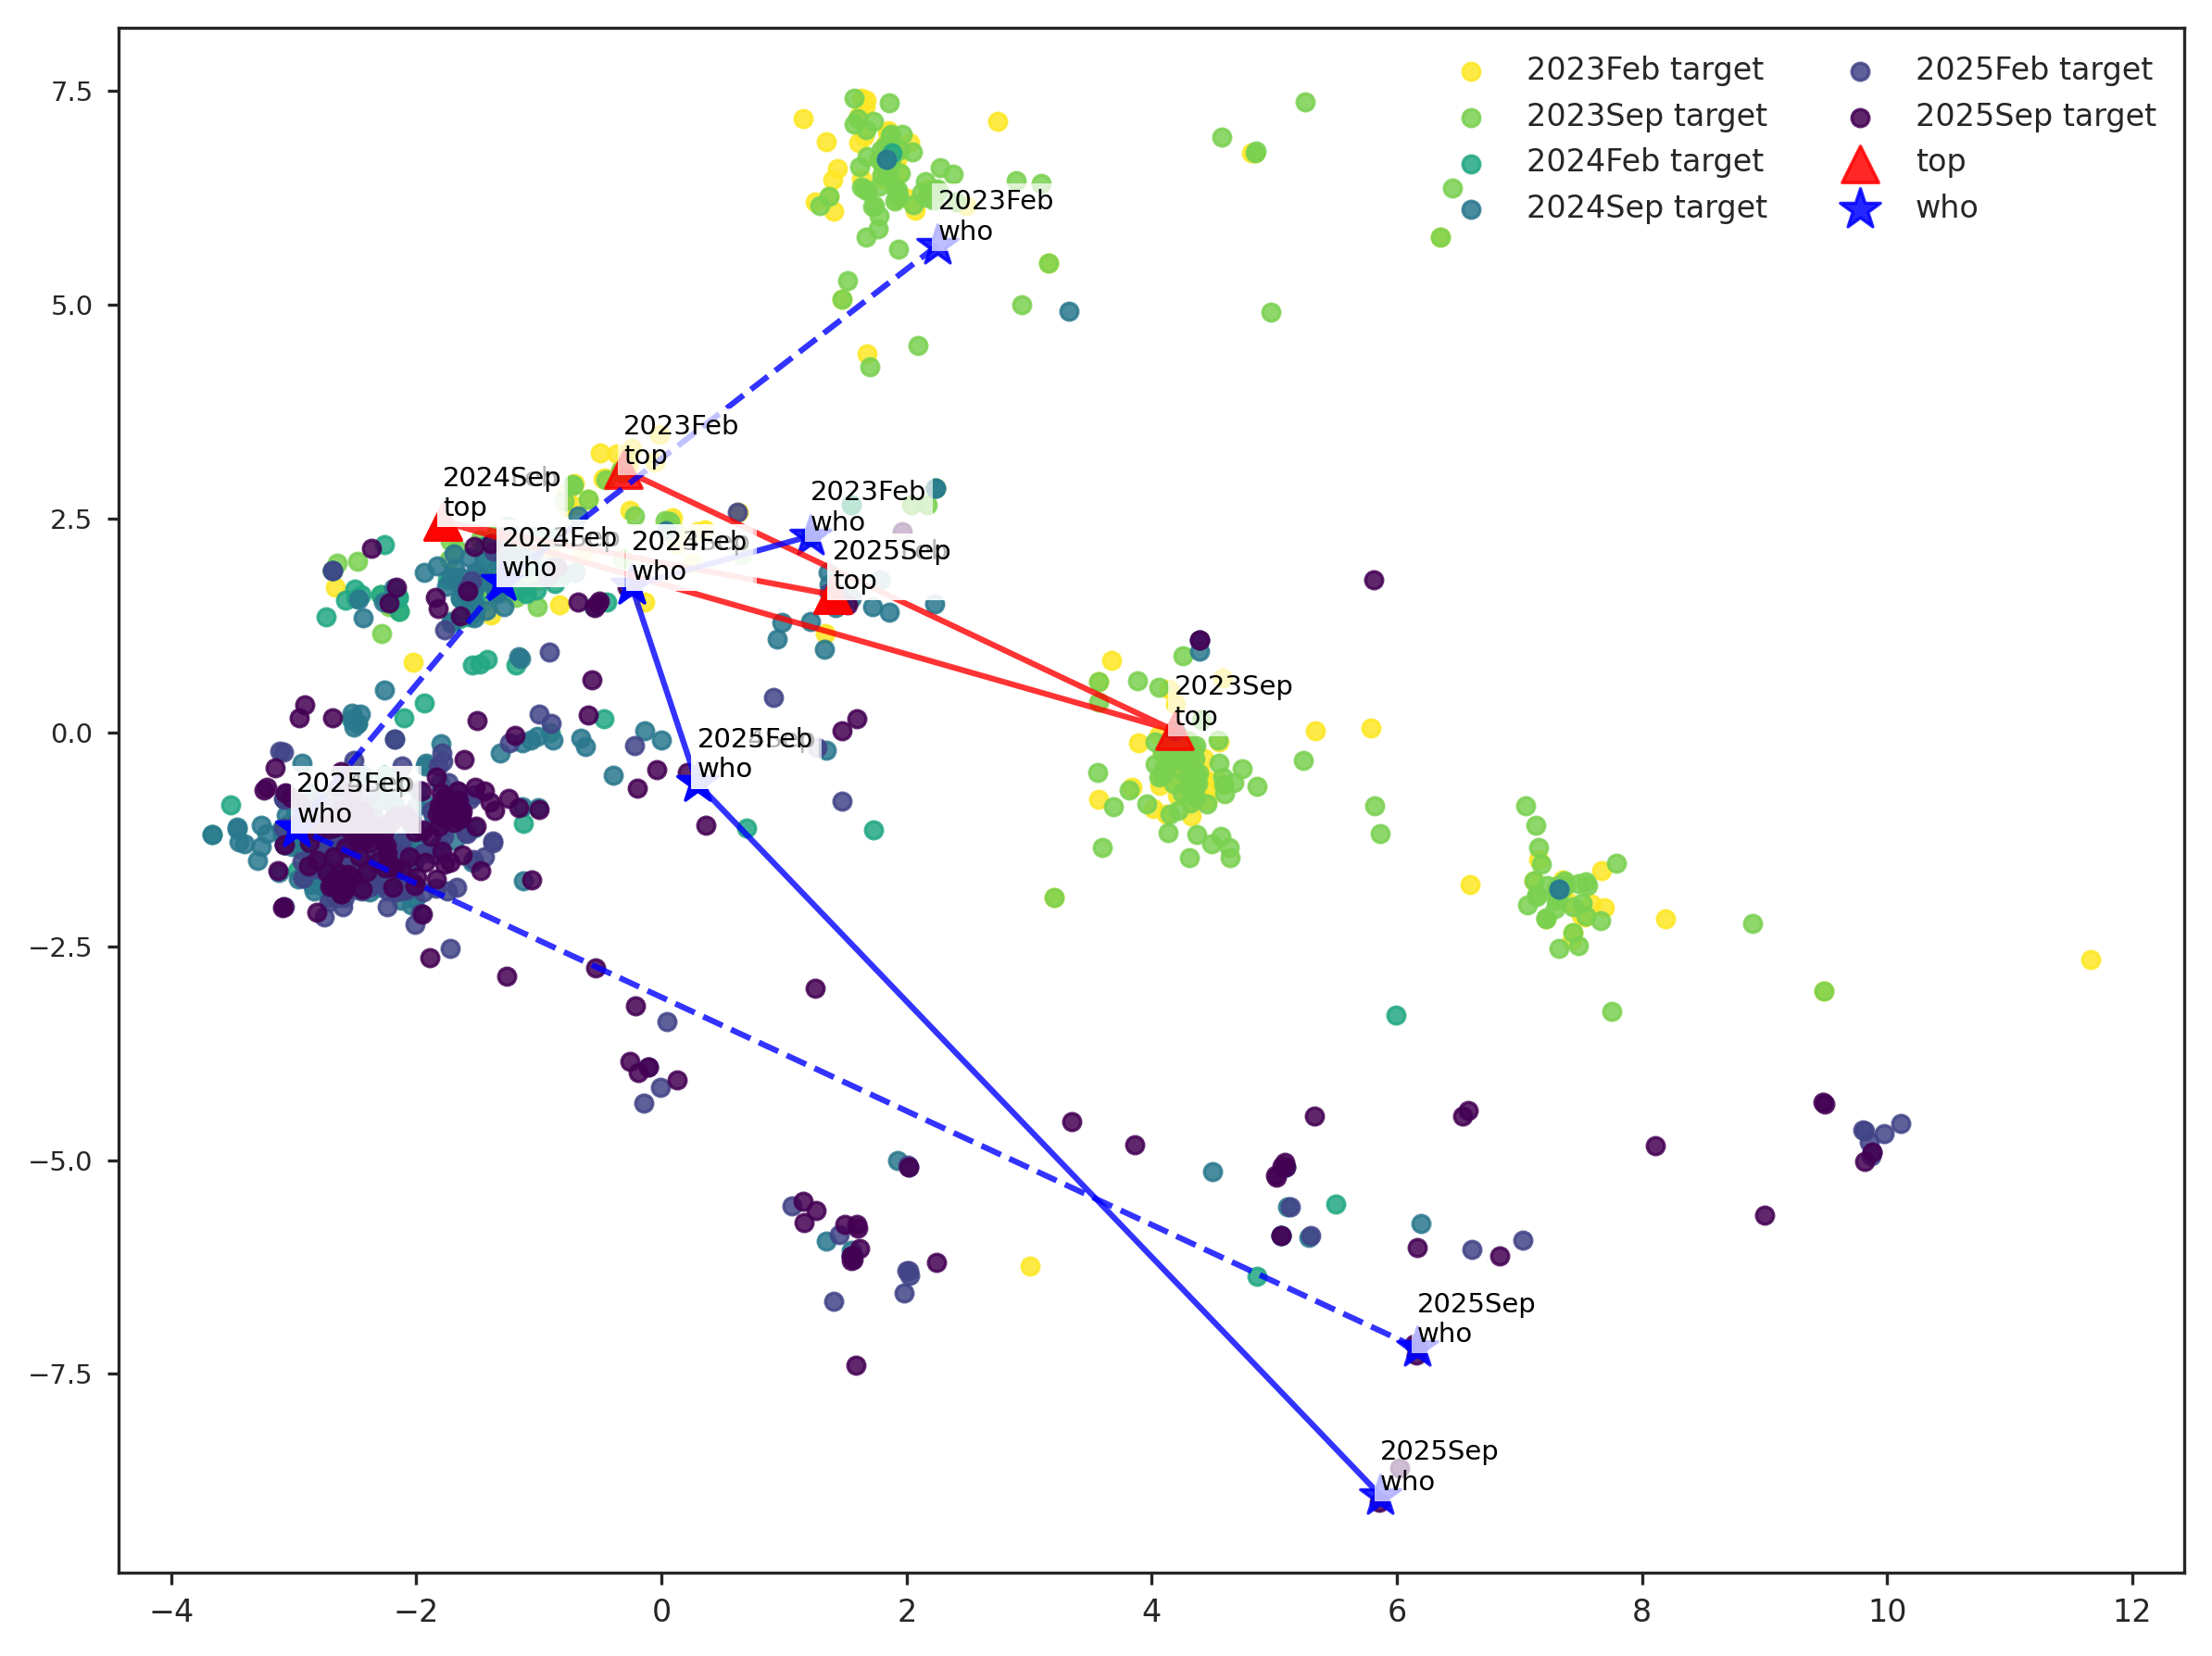

In [37]:
season_inputs = {
    "2023Feb": {
        "emb_dict": emb_dict_2023Feb,
        "target_ids": virus_id_2023Feb,
        "top_id": top_id_2023Feb,
        "who_ids": who_id_2023Feb,
    },
    "2023Sep": {
        "emb_dict": emb_dict_2023Sep,
        "target_ids": virus_id_2023Sep,
        "top_id": top_id_2023Sep,
        "who_ids": who_id_2023Sep,
    },
    "2024Feb": {
        "emb_dict": emb_dict_2024Feb,
        "target_ids": virus_id_2024Feb,
        "top_id": top_id_2024Feb,
        "who_ids": who_id_2024Feb,
    },
    "2024Sep": {
        "emb_dict": emb_dict_2024Sep,
        "target_ids": virus_id_2024Sep,
        "top_id": top_id_2024Sep,
        "who_ids": who_id_2024Sep,
    },
    "2025Feb": {
        "emb_dict": emb_dict_2025Feb,
        "target_ids": virus_id_2025Feb,
        "top_id": top_id_2025Feb,
        "who_ids": who_id_2025Feb,
    },
    "2025Sep": {
        "emb_dict": emb_dict_2025Sep,
        "target_ids": virus_id_2025Sep,
        "top_id": top_id_2025Sep,
        "who_ids": who_id_2025Sep,
    },
}

all_map_df, season_colors = plot_all_target_top_who(season_inputs)

In [38]:
def plot_one_season_from_global(all_map_df, season, season_colors, figsize=(5, 4), xlim=None, ylim=None):
    import matplotlib.pyplot as plt
    import matplotlib.patheffects as pe

    df = all_map_df[all_map_df["season"] == season].copy()

    colors = {
        "target": season_colors[season],
        "top": "red",
        "who": "blue",
    }
    markers = {"target": "o", "top": "^", "who": "*"}
    sizes = {"target": 25, "top": 100, "who": 130}

    plt.figure(figsize=figsize)
    for group in ["target", "top", "who"]:
        sub = df[df["group"] == group]
        if len(sub) == 0:
            continue
        plt.scatter(
            sub["x"], sub["y"],
            c=[colors[group]],
            marker=markers[group],
            s=sizes[group],
            alpha=0.85,
            label=group
        )

    for _, r in df[df["group"] != "target"].iterrows():
        txt = plt.text(
            r["x"], r["y"],
            r["group"],
            fontsize=8,
            color="black",
            ha="left",
            va="bottom"
        )
        txt.set_path_effects([pe.withStroke(linewidth=3, foreground="white")])

    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.title(season)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

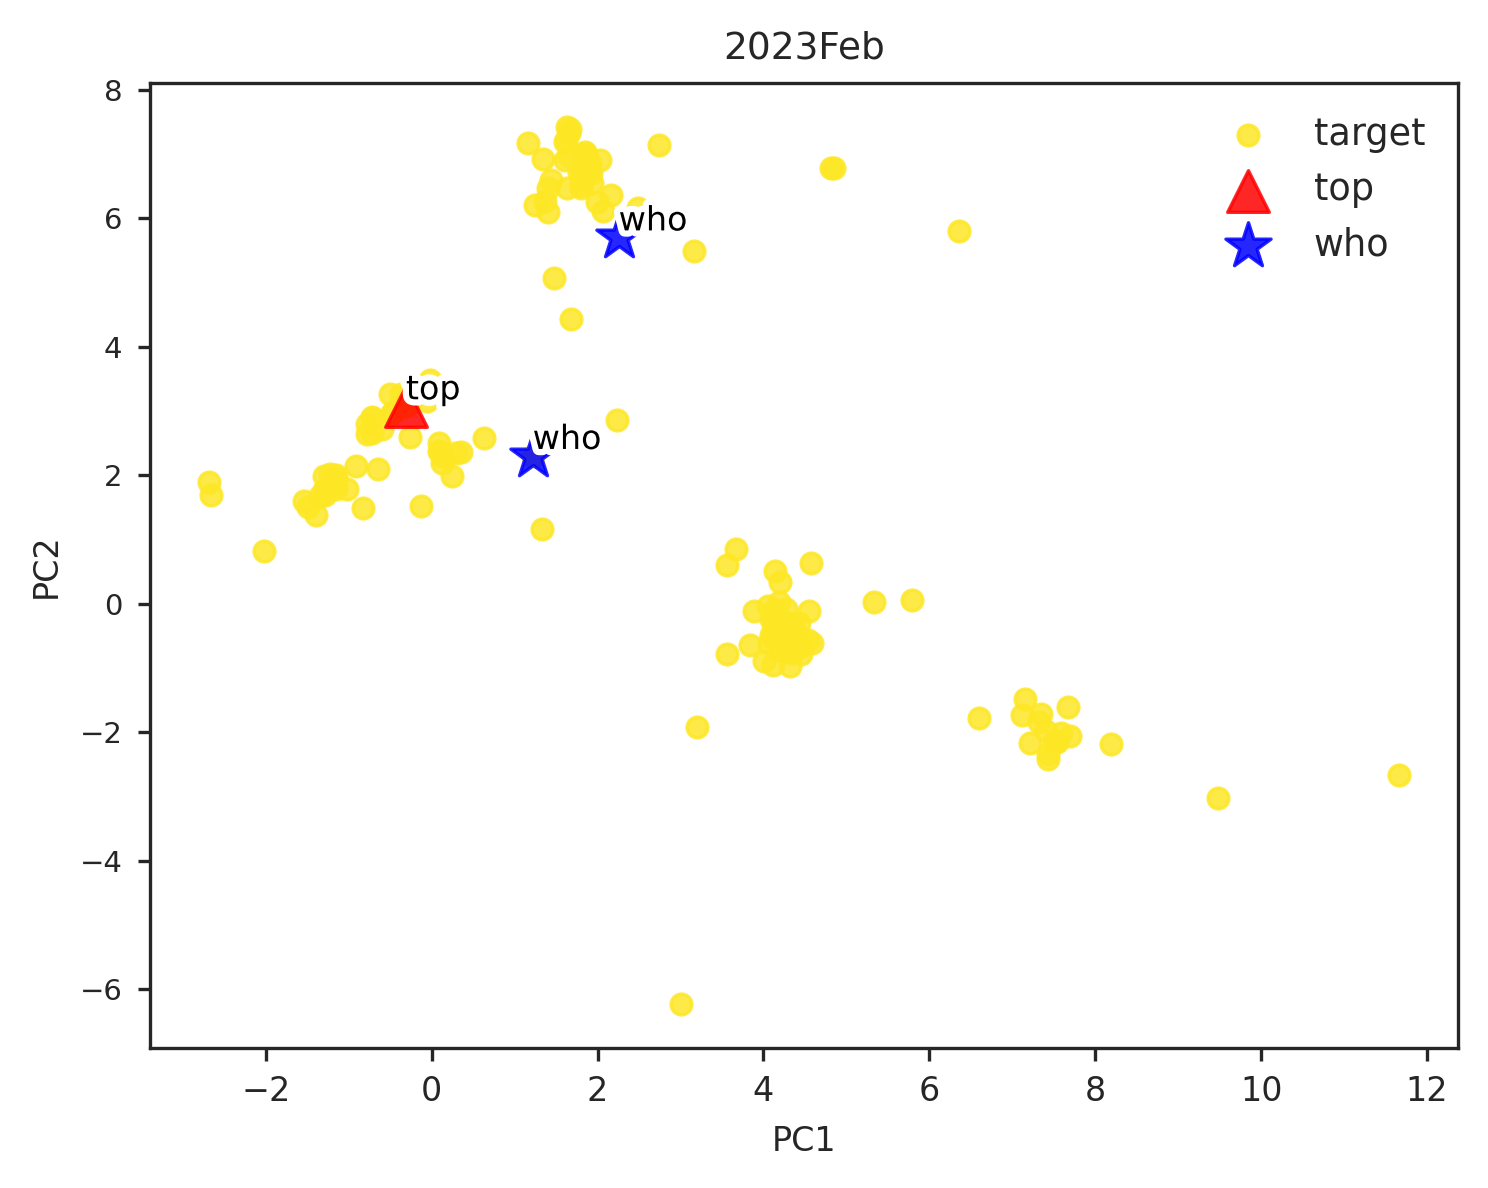

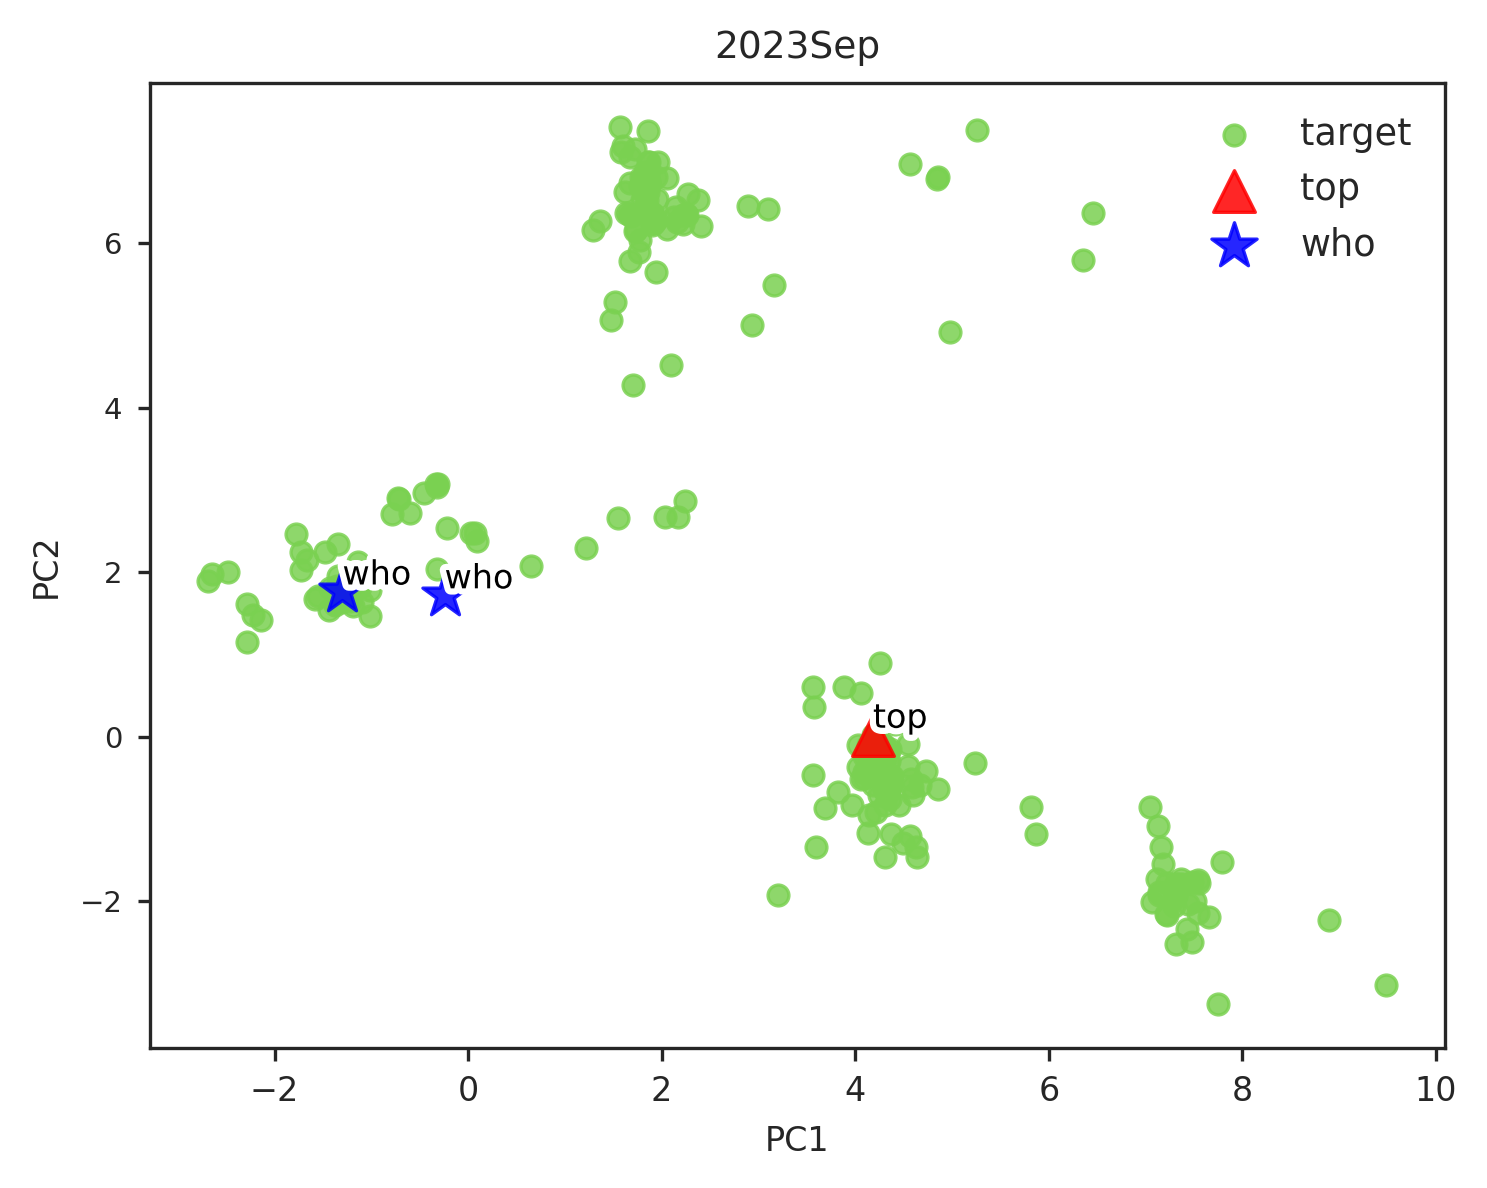

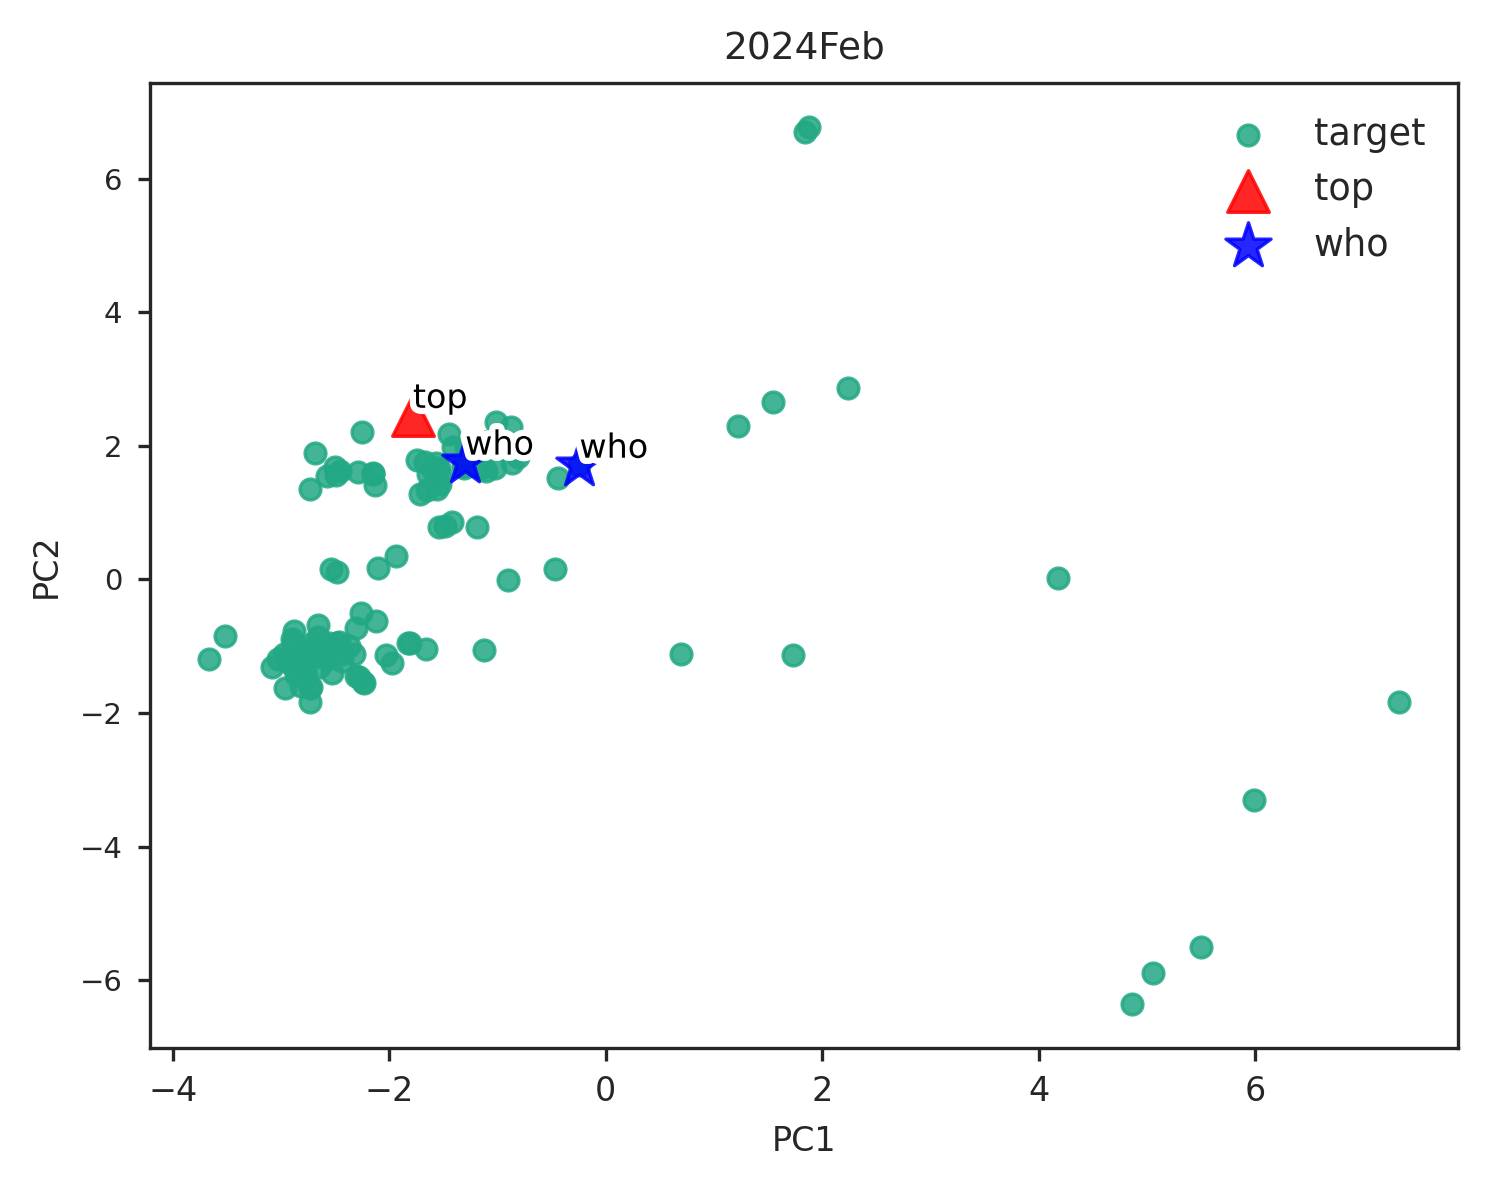

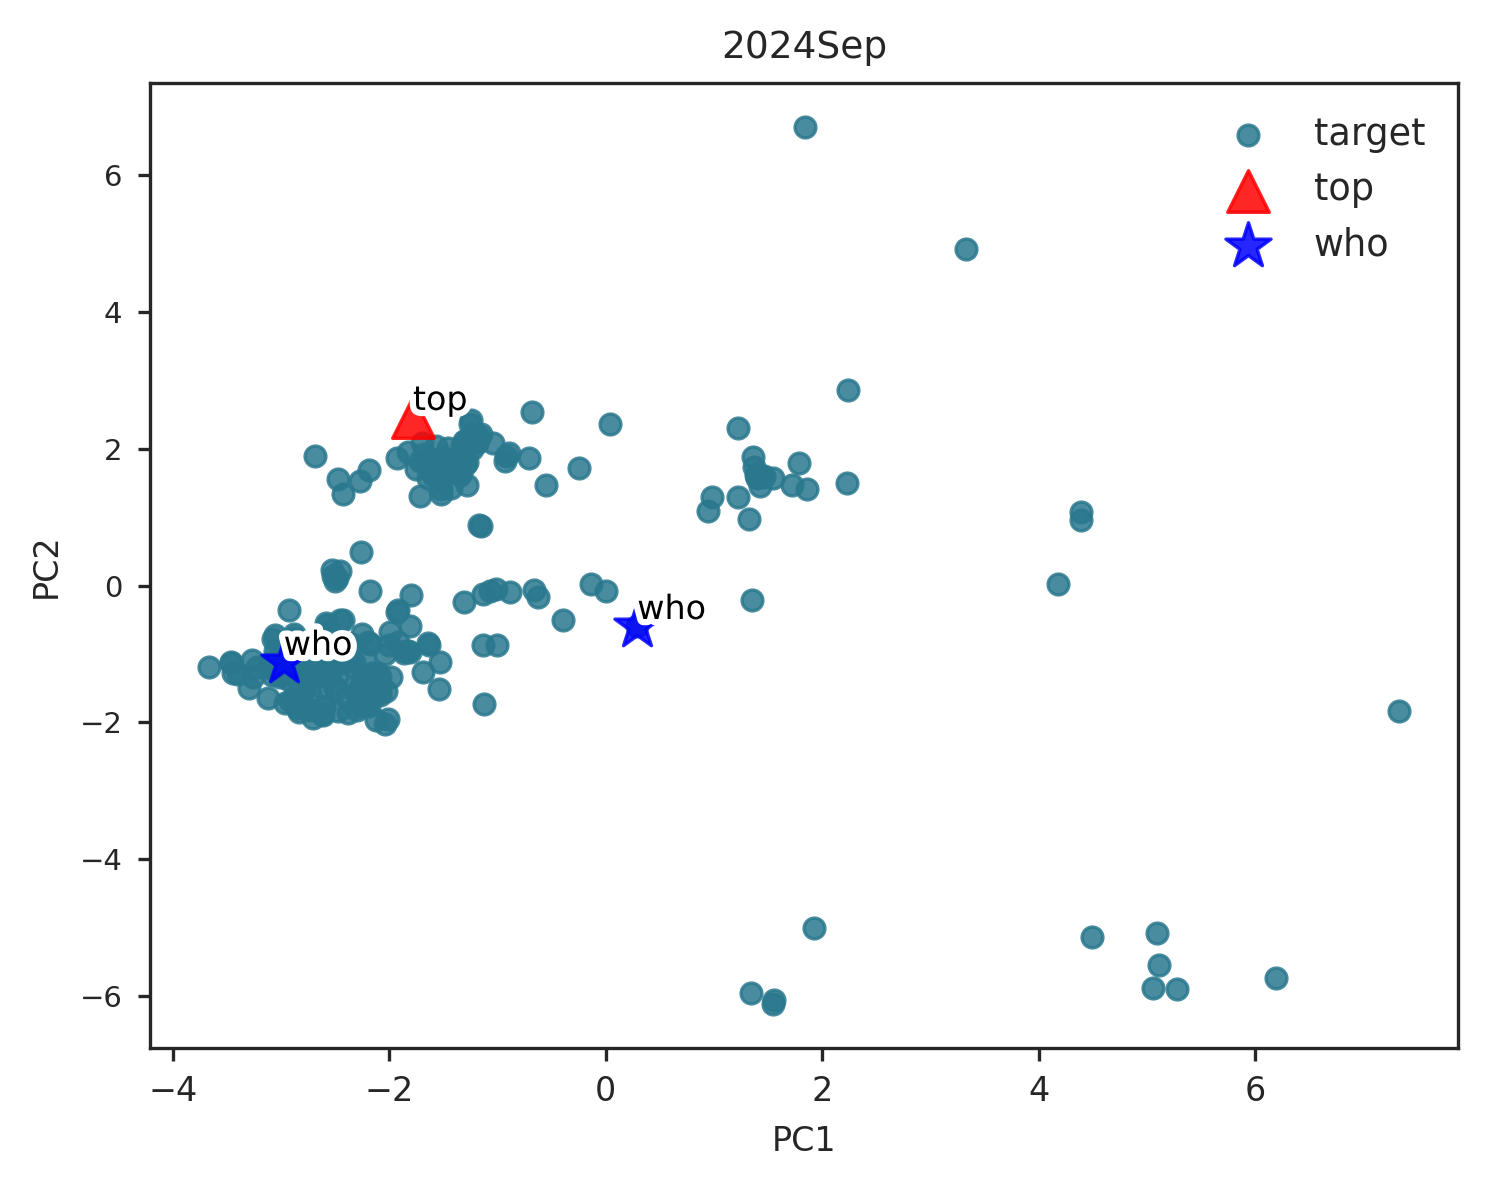

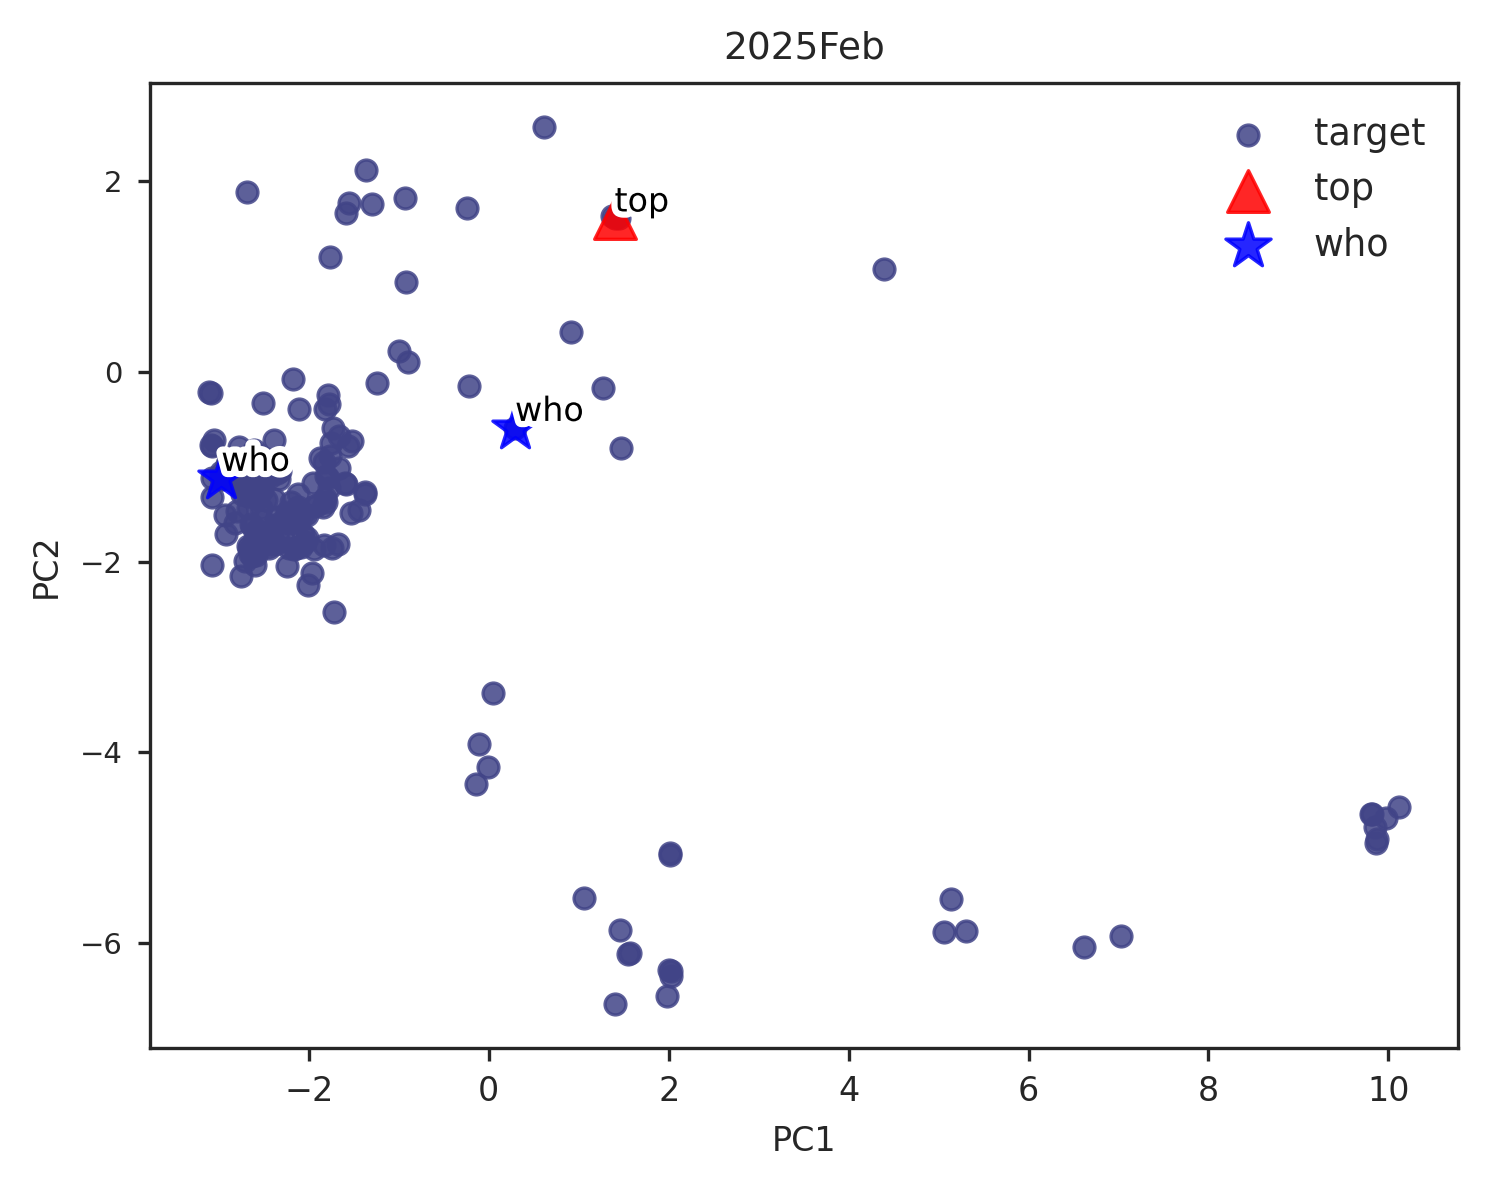

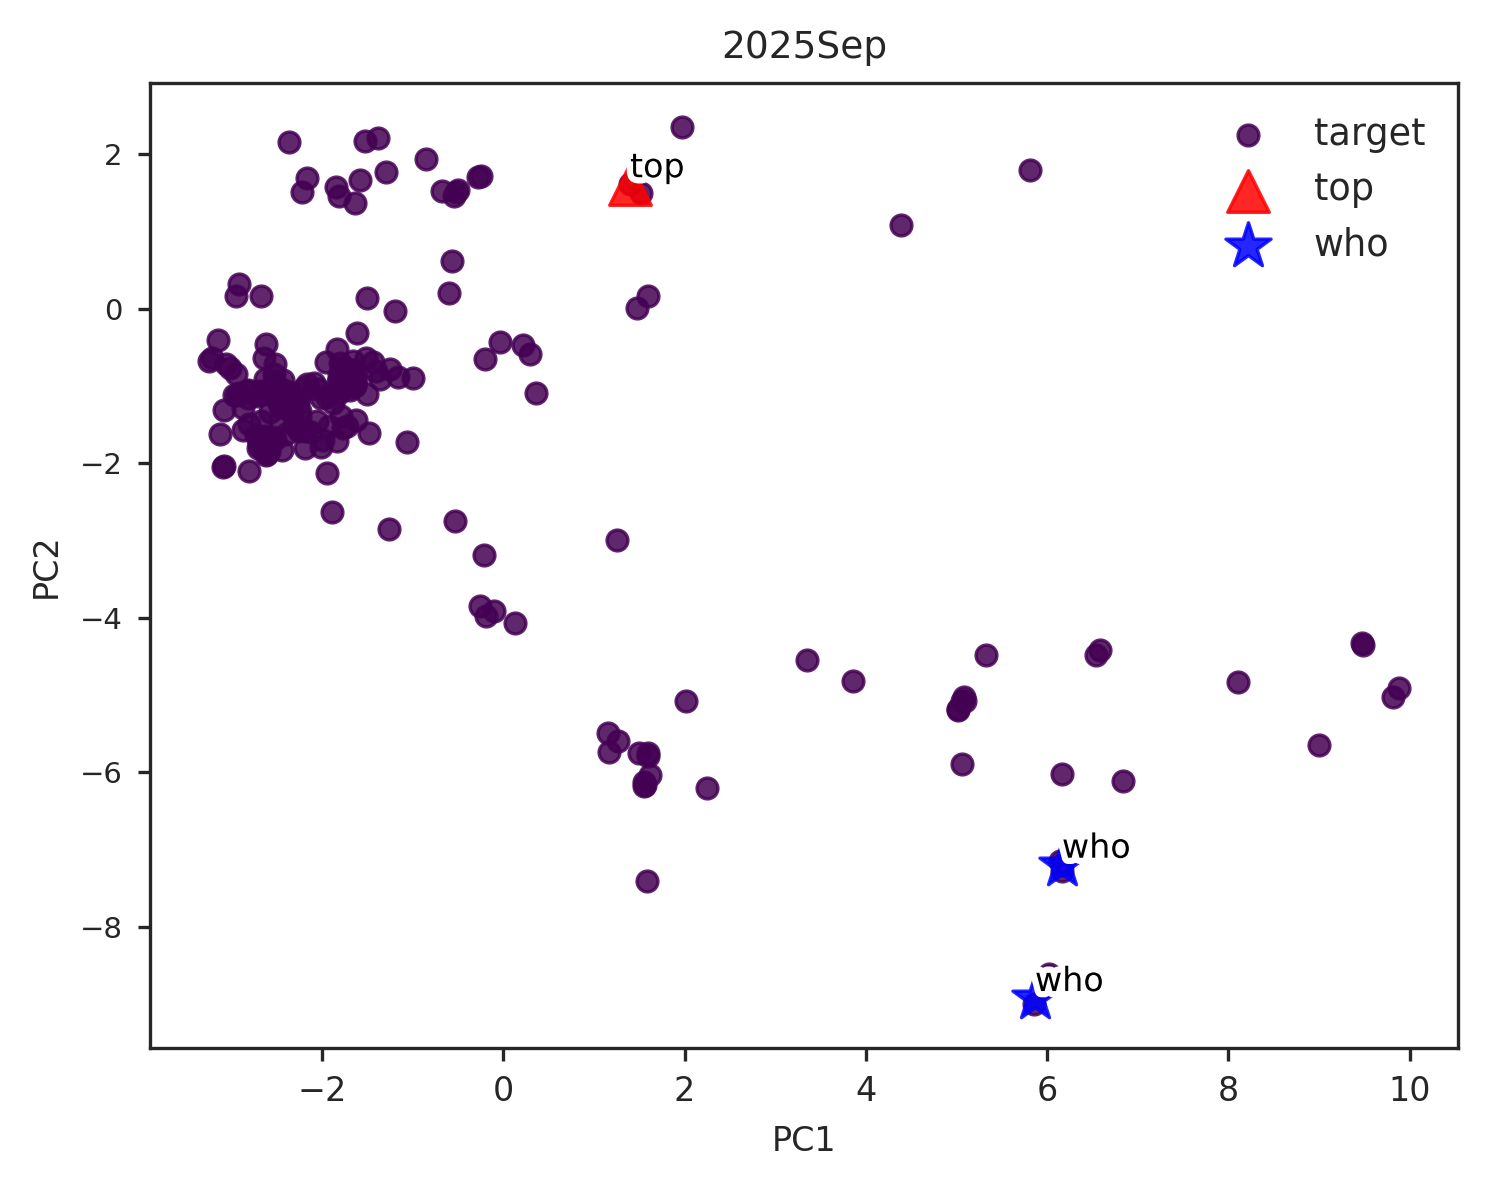

In [39]:
plot_one_season_from_global(all_map_df, "2023Feb", season_colors)
plot_one_season_from_global(all_map_df, "2023Sep", season_colors)
plot_one_season_from_global(all_map_df, "2024Feb", season_colors)
plot_one_season_from_global(all_map_df, "2024Sep", season_colors)
plot_one_season_from_global(all_map_df, "2025Feb", season_colors)
plot_one_season_from_global(all_map_df, "2025Sep", season_colors)

## 3. 六个季节：WHO 与 fluVaxSelector 对比（鸡胚 / 细胞系分列）

In [26]:
all_selected = []

for season in ['2023Feb', '2023Sep', '2024Feb', '2024Sep', '2025Feb', '2025Sep']:
    season_vacs = globals()[f'vaccine_{season}']
    who_vacs = globals()[f'who_{season}']

    # 保持为 DataFrame，不要变成 Series
    flu_strain = season_vacs.iloc[[0], :].loc[:, ['seq_a', 'serumIslID', 'vaccine']].copy()
    flu_strain['source'] = 'fluVacSelector'
    flu_strain['season'] = season

    who_strain = season_vacs.loc[
        season_vacs['vaccine'].isin(who_vacs),
        ['seq_a', 'serumIslID', 'vaccine']
    ].copy()
    who_strain['source'] = 'who'
    who_strain['season'] = season

    selected_strain = pd.concat([flu_strain, who_strain], ignore_index=True)
    all_selected.append(selected_strain)

selected_strain = pd.concat(all_selected, ignore_index=True)

In [63]:
ddd.loc[ddd['source'] == 'fluVacSelector', 'vaccine'].str.split(" ").item()[1]

'CELL'

In [69]:
season = '2023Sep'

ddd = selected_strain[selected_strain['season'] == season]
flu_seq = ddd.loc[ddd['source'] == 'fluVacSelector', 'seq_a'].item()
passage = ddd.loc[ddd['source'] == 'fluVacSelector', 'vaccine'].str.split(" ").item()[1]
who_seq = ddd.loc[(ddd['source'] == 'who') & (ddd['vaccine'].str.endswith(passage)), 'seq_a'].item()
diffs = [(i - 16, c1, c2) for i, (c1, c2) in enumerate(zip(flu_seq, who_seq)) if c1 != c2]
print(diffs)

[(-14, 'T', 'A'), (52, 'D', 'N'), (78, 'V', 'F'), (95, 'N', 'S'), (155, 'H', 'S'), (191, 'I', 'F'), (222, 'I', 'V'), (261, 'N', 'S'), (377, 'N', 'S')]


In [78]:
diff_list = []
vac_names = []   # 新增：保存每个 season 对应的毒株名字

for season in ['2023Feb', '2023Sep', '2024Feb', '2024Sep', '2025Feb', '2025Sep']:
    ddd = selected_strain[selected_strain['season'] == season]

    flu_row = ddd.loc[ddd['source'] == 'fluVacSelector'].iloc[0]
    flu_seq = flu_row['seq_a']
    flu_name = flu_row['vaccine']  # fluVacSelector 毒株名

    passage = flu_name.split(" ")[1]

    who_row = ddd.loc[(ddd['source'] == 'who') & (ddd['vaccine'].str.endswith(passage))].iloc[0]
    who_seq = who_row['seq_a']
    who_name = who_row['vaccine']  # WHO 毒株名

    diff_pos = [
        (i - 16, c1, c2)
        for i, (c1, c2) in enumerate(zip(flu_seq, who_seq))
        if (c1 != c2) and (i > 16) and (i <= 345)
    ]

    diff_list.append(diff_pos)
    vac_names.append((season, flu_name, who_name))

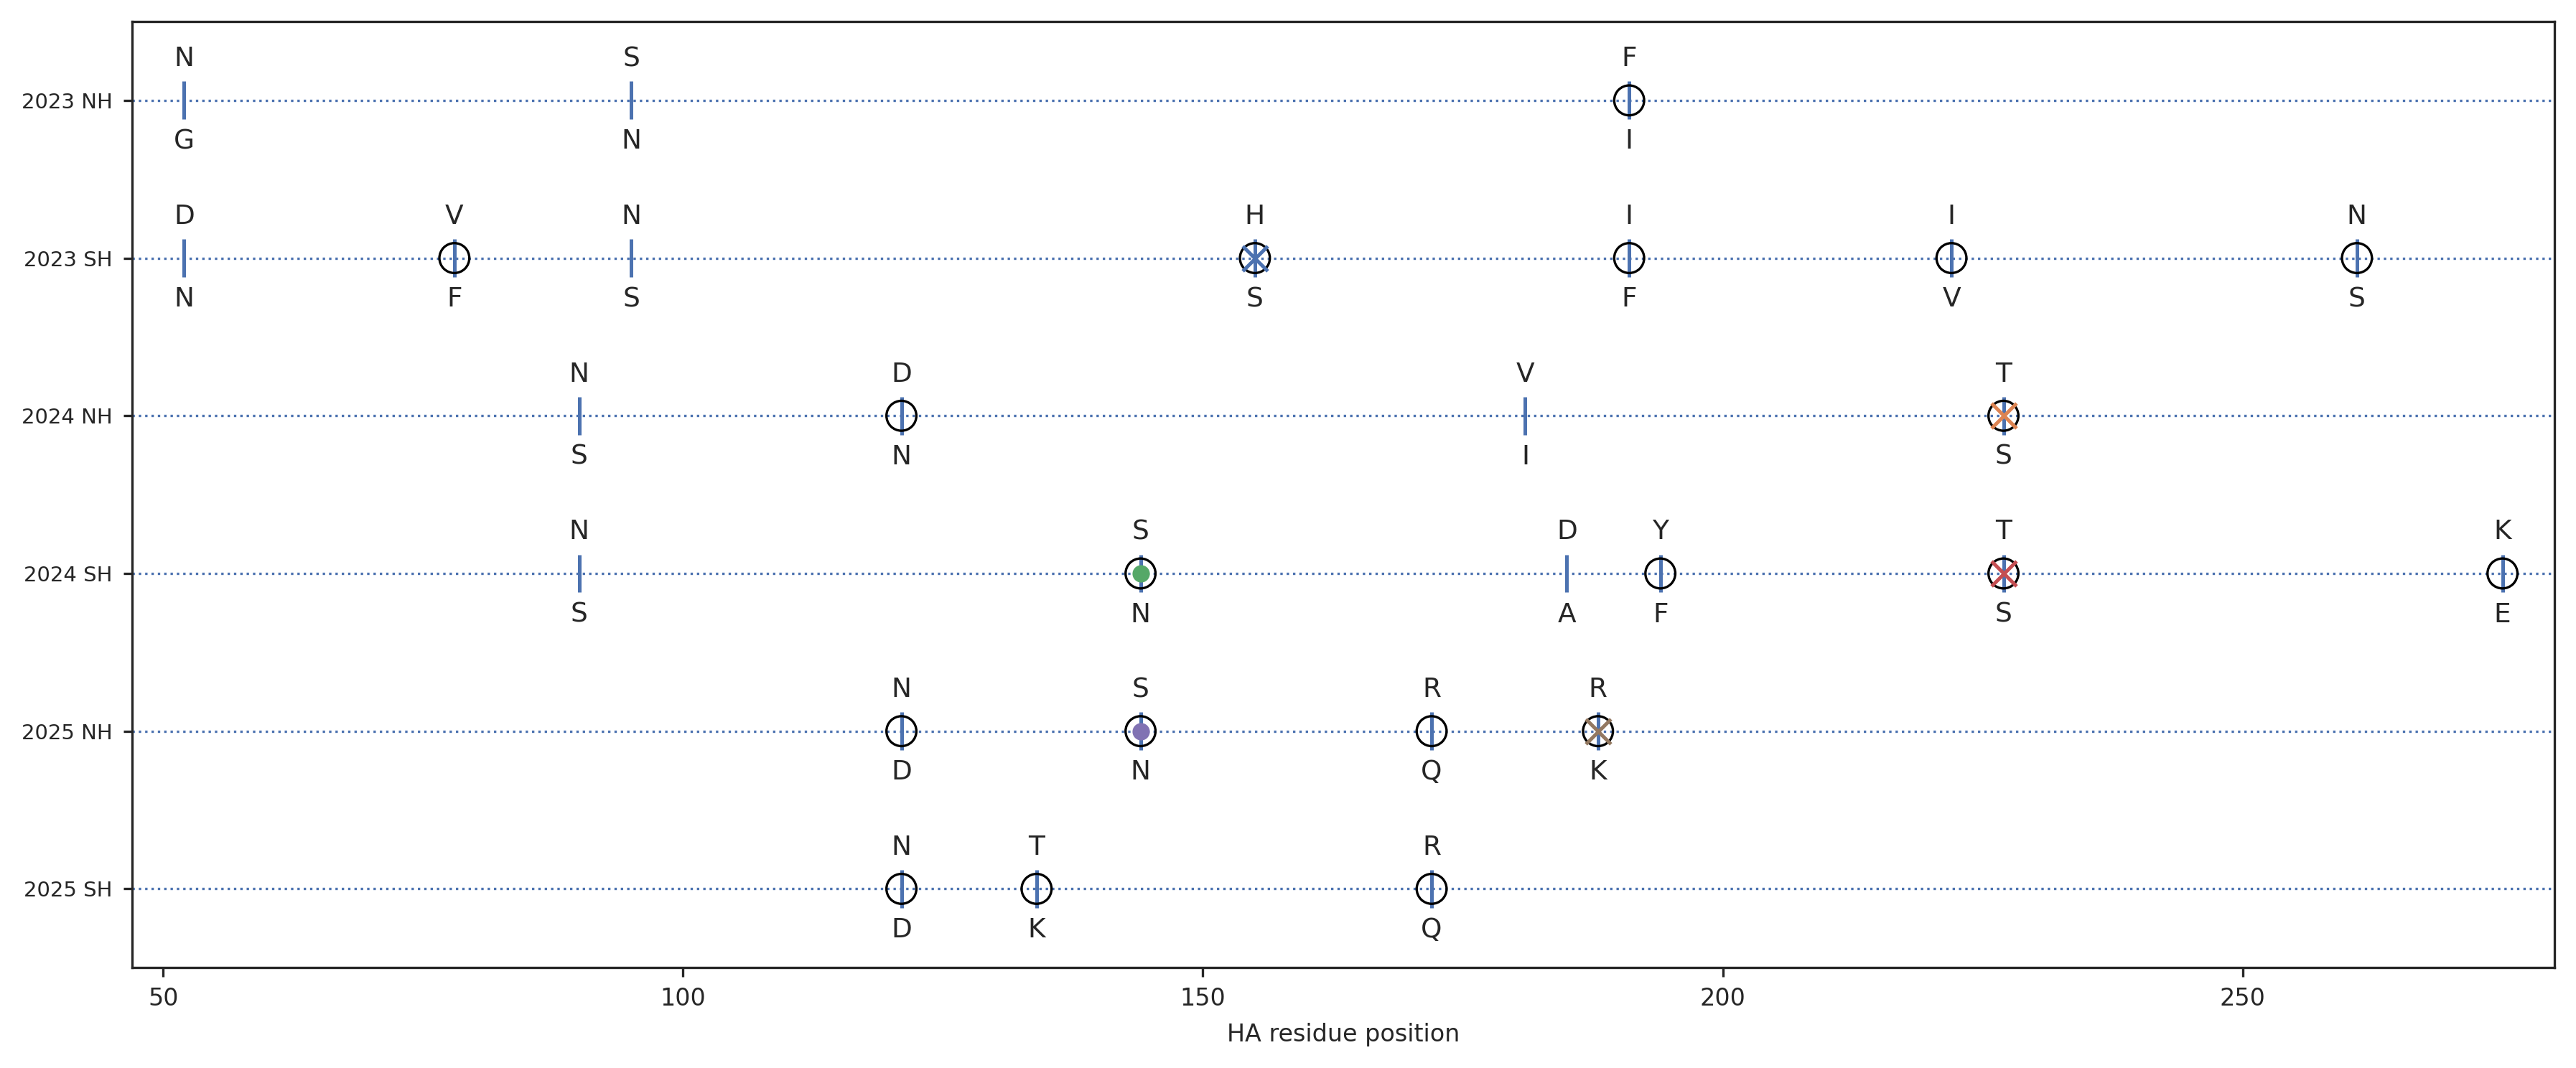

In [ ]:
import matplotlib.pyplot as plt

row_labels = [f"{season} | {flu_name} vs {who_name}" for season, flu_name, who_name in vac_names]
if len(row_labels) != len(diff_list):
    raise ValueError("row_labels 和 diff_list 长度不一致，请检查 vac_names 的构建顺序")

# 按需填写；不  想分类就都设为空 set()
epitope_A = [122, 124, 126, 131, 133, 134, 135, 136, 137, 138, 139, 140, 142, 143, 144, 145, 146]
epitope_B = [128, 155, 156, 157, 158, 159, 160, 163, 164, 165, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198]
epitope_C = [45, 48, 50, 53, 54, 55, 56, 275, 276, 278, 279, 285, 299, 307, 312]
epitope_D = [121, 171, 172, 173, 174, 201, 207, 208, 209, 213, 217, 219, 220, 222, 225, 226, 227, 242, 244, 246, 247, 248]
epitope_E = [57, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 88, 92, 94, 260, 261, 262]
antigenic_sites = epitope_A + epitope_B + epitope_C + epitope_D + epitope_E
rbs_sites = [135, 137, 155, 188, 190, 225, 226, 227]
glyco_sites = [45, 122, 133, 144, 246, 285]

ys = list(range(len(diff_list), 0, -1))
all_pos = [p for group in diff_list for p, _, _ in group]

plt.figure(figsize=(12, 5))

for y, group in zip(ys, diff_list):
    plt.hlines(y, min(all_pos)-5, max(all_pos)+5, linestyles=':', linewidth=0.8)
    for pos, aa1, aa2 in group:
        plt.vlines(pos, y-0.12, y+0.12, linewidth=1.2)
        if pos in antigenic_sites:
            plt.scatter(pos, y, s=100, facecolors='none', edgecolors='black', zorder=3)
        if pos in glyco_sites:
            plt.scatter(pos, y, s=25, zorder=4)
        if pos in rbs_sites:
            plt.scatter(pos, y, marker='x', s=70, zorder=5)
        plt.text(pos, y+0.18, aa1, ha='center', va='bottom', fontsize=9)
        plt.text(pos, y-0.18, aa2, ha='center', va='top', fontsize=9)

# for season in 

plt.yticks(ys, row_labels)
plt.xlabel('HA residue position')
plt.xlim(min(all_pos)-5, max(all_pos)+5)
plt.ylim(0.5, len(diff_list)+0.5)
plt.tight_layout()
plt.show()